# EV model fitting — presentation figures

Visualize steps of the EV demand pipeline under the current scenario config
(`utils/EVs/configs/md_2024.yaml`). Later cells can swap charging policies.

1. **Adoption** — NREL conditional P(EV) by FPL / building type / tenure, then Bernoulli sample on ResStock
2. **Profile matching** — NHTS match-tier fallbacks, and how driving profiles differ by urban/rural, income, occupants, weekday/weekend
3. **Annual driving** — replay matched weekday/weekend templates over the config year with time/miles noise
4. **Battery assignment** — stock-conditional draws from ResStock BEV options vs national prior shares
5. **Charging policies** — single-building charge/discharge, then fleet aggregate hourly load (first week of July)


In [1]:
import logging
import sys
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

BSF_ROOT = Path("/ebs/home/lily_switch_box/buildstock-fetch")
if str(BSF_ROOT) not in sys.path:
    sys.path.insert(0, str(BSF_ROOT))

from utils.EVs.EVAdoptionSampler import EVAdoptionSampler
from utils.EVs.EVBatteryAssigner import EVBatteryAssigner
from utils.EVs.ChargingSimulator import ChargingSimulator
from utils.EVs.NHTSProfileSampler import NHTSProfileSampler, summarize_nhts_match_catalog
from utils.EVs.TripScheduleGenerator import TripScheduleGenerator, iter_travel_day_starts
from utils.EVs.charging import (
    DEFAULT_SOC_MIN_FRACTION,
    DEFAULT_SOC_SAFETY_BUFFER_FRACTION,
    build_hours_base,
)
from utils.EVs.ev_demand import load_ev_demand_config
from utils.EVs.ev_utils import (
    load_ev_autonomie_params,
    load_ev_battery_lookup,
    load_ev_ownership_lookup,
    load_metadata,
    load_nhts_data,
    state_ev_ownership_rate,
)

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

# Presentation colors
COLOR_PINK = "#D86ECC"
COLOR_GREEN = "#3B7D23"


In [2]:
# Scenario config — change this path to compare other states / charging policies later
CONFIG_PATH = BSF_ROOT / "utils/EVs/configs/md_2024.yaml"

config = load_ev_demand_config(CONFIG_PATH)
STATE = config.state
SEED = config.random_state

print(f"state={STATE}  release={config.release}  seed={SEED}")
print(f"ev_assignment={config.ev_assignment}")
print(f"charging_strategy={config.charging_strategy}")
print(f"metadata: {config.metadata_path}")
print(f"ev_ownership: {config.ev_ownership_path}")


state=MD  release=res_2024_tmy3_2  seed=42
ev_assignment=resstock_adoption
charging_strategy=off_peak_immediate
metadata: /ebs/home/lily_switch_box/buildstock-fetch/utils/EVs/ev_data/inputs/res_2024_tmy3_2/metadata/MD/metadata.parquet
ev_ownership: /ebs/home/lily_switch_box/buildstock-fetch/utils/EVs/ev_data/inputs/resstock_ev_reference/Electric_Vehicle_Ownership.tsv


In [3]:
# Core inputs for adoption + NHTS matching (battery tables loaded in §6)
assert config.metadata_path is not None
assert config.ev_ownership_path is not None

metadata_df = load_metadata(config.metadata_path, STATE)
ev_lookup = load_ev_ownership_lookup(config.ev_ownership_path, STATE)
state_rate = state_ev_ownership_rate(ev_lookup, STATE)

print(f"Metadata buildings: {metadata_df.height:,}")
print(f"Occupied: {metadata_df.filter(~pl.col('is_vacant')).height:,}")
print(f"EV lookup rows ({STATE}): {ev_lookup.height:,}")
print(f"PUMS-weighted statewide P(EV): {state_rate:.4f} ({state_rate:.2%})")


Metadata buildings: 9,001
Occupied: 9,001
EV lookup rows (MD): 4,620
PUMS-weighted statewide P(EV): 0.0178 (1.78%)


## Plot helpers

Bar charts of mean P(EV) by FPL / building type / tenure. For each category we show:

- **weighted** — weight-weighted mean (lookup `source_weight`, or ResStock `weight`)
- **unweighted** — simple mean across lookup segments or buildings


In [4]:
FPL_ORDER = ["0-100%", "100-150%", "150-200%", "200-300%", "300-400%", "400%+"]
PLOT_CATEGORIES = ["fpl", "building_type", "tenure"]
PLOT_CATEGORY_LABELS = {
    "fpl": "Federal poverty level",
    "building_type": "Building type",
    "tenure": "Tenure",
}


def ev_prob_summaries(
    df: pl.DataFrame,
    category: str,
    weight_col: str,
    prob_col: str = "ev_ownership_probability",
) -> pl.DataFrame:
    """Conditional = weight-weighted mean P(EV); categorical = unweighted mean."""
    data = df.filter(
        (pl.col("tenure") != "Not Available")
        & (pl.col("fpl") != "Not Available")
        & (pl.col(category) != "Not Available")
    )
    prob = pl.col(prob_col).cast(pl.Float64)
    return data.group_by(category).agg(
        ((prob * pl.col(weight_col)).sum() / pl.col(weight_col).sum()).alias("conditional_p_ev"),
        prob.mean().alias("categorical_p_ev"),
        pl.col(weight_col).sum().alias("total_weight"),
        pl.len().alias("n"),
    )


def ev_distribution_summaries(
    df: pl.DataFrame,
    category: str,
    weight_col: str,
    *,
    has_ev_col: str = "has_ev",
) -> pl.DataFrame:
    """Share of sampled EVs in each category (composition of the EV fleet).

    Includes every category present in the eligible building stock, with
    zero height / n_evs=0 when no EVs were assigned to that category.
    """
    eligible = df.filter(
        (pl.col("tenure") != "Not Available")
        & (pl.col("fpl") != "Not Available")
        & (pl.col(category) != "Not Available")
    )
    # Keep FPL axis stable even if a bin is missing from this sample
    if category == "fpl":
        all_cats = pl.DataFrame({category: FPL_ORDER})
    else:
        all_cats = eligible.select(category).unique()

    evs = eligible.filter(pl.col(has_ev_col).cast(pl.Boolean))
    total_n = evs.height
    total_w = float(evs[weight_col].sum()) if total_n else 0.0
    summary = evs.group_by(category).agg(
        pl.len().alias("n_evs"),
        pl.col(weight_col).sum().alias("ev_weight"),
    )
    summary = all_cats.join(summary, on=category, how="left").with_columns(
        pl.col("n_evs").fill_null(0),
        pl.col("ev_weight").fill_null(0.0),
    )
    if total_n == 0:
        return summary.with_columns(
            pl.lit(0.0).alias("share_unweighted"),
            pl.lit(0.0).alias("share_weighted"),
        )
    return summary.with_columns(
        (pl.col("n_evs") / total_n).alias("share_unweighted"),
        (pl.col("ev_weight") / total_w).alias("share_weighted"),
    )


def _sort_summary(summary: pl.DataFrame, category: str) -> pl.DataFrame:
    if category == "fpl":
        order = {v: i for i, v in enumerate(FPL_ORDER)}
        return summary.sort(pl.col(category).replace(order))
    return summary.sort(category)


def plot_ev_probs_by_category(
    df: pl.DataFrame,
    *,
    weight_col: str,
    title: str,
    prob_col: str = "ev_ownership_probability",
    color: str = "#D86ECC",
) -> None:
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    fig.suptitle(title, fontsize=14, y=1.01)

    for row, category in enumerate(PLOT_CATEGORIES):
        summary = _sort_summary(ev_prob_summaries(df, category, weight_col, prob_col), category)
        labels = summary[category].to_list()
        x = range(len(labels))

        panels = [
            ("conditional_p_ev", f"P(EV | {PLOT_CATEGORY_LABELS[category]}) — weighted"),
            ("categorical_p_ev", f"P(EV | {PLOT_CATEGORY_LABELS[category]}) — unweighted mean"),
        ]
        for col, (metric, subtitle) in enumerate(panels):
            ax = axes[row, col]
            vals = summary[metric].to_numpy()
            bars = ax.bar(x, vals, color=color)
            ax.set_ylabel("P(EV)")
            ax.set_title(subtitle, fontsize=10)
            ax.set_xticks(list(x))
            ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
            for bar, val in zip(bars, vals, strict=False):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    f"{val:.1%}",
                    ha="center",
                    va="bottom",
                    fontsize=7,
                )

    fig.tight_layout()
    plt.show()


def plot_ev_distribution_by_category(
    df: pl.DataFrame,
    *,
    weight_col: str,
    title: str,
    has_ev_col: str = "has_ev",
    color: str = "#D86ECC",
) -> None:
    """Bar charts of EV fleet composition by FPL / building type / tenure."""
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    fig.suptitle(title, fontsize=14, y=1.01)

    for row, category in enumerate(PLOT_CATEGORIES):
        summary = _sort_summary(
            ev_distribution_summaries(df, category, weight_col, has_ev_col=has_ev_col),
            category,
        )
        labels = summary[category].to_list()
        x = range(len(labels))

        panels = [
            ("share_weighted", f"Share of EVs by {PLOT_CATEGORY_LABELS[category]} — weighted"),
            ("share_unweighted", f"Share of EVs by {PLOT_CATEGORY_LABELS[category]} — unweighted"),
        ]
        for col, (metric, subtitle) in enumerate(panels):
            ax = axes[row, col]
            vals = summary[metric].to_numpy()
            bars = ax.bar(x, vals, color=color)
            ax.set_ylabel("Share of EVs")
            ax.set_title(subtitle, fontsize=10)
            ax.set_xticks(list(x))
            ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
            for bar, val, n in zip(bars, vals, summary["n_evs"].to_list(), strict=False):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    f"{val:.0%}\n(n={n})",
                    ha="center",
                    va="bottom",
                    fontsize=7,
                )

    fig.tight_layout()
    plt.show()


## 1. NREL lookup adoption rates

Conditional P(EV) from `Electric_Vehicle_Ownership.tsv`, filtered to this config's state.
Occupied segments only (`tenure != Not Available`).


P(EV) range: 0.0000 – 0.0912


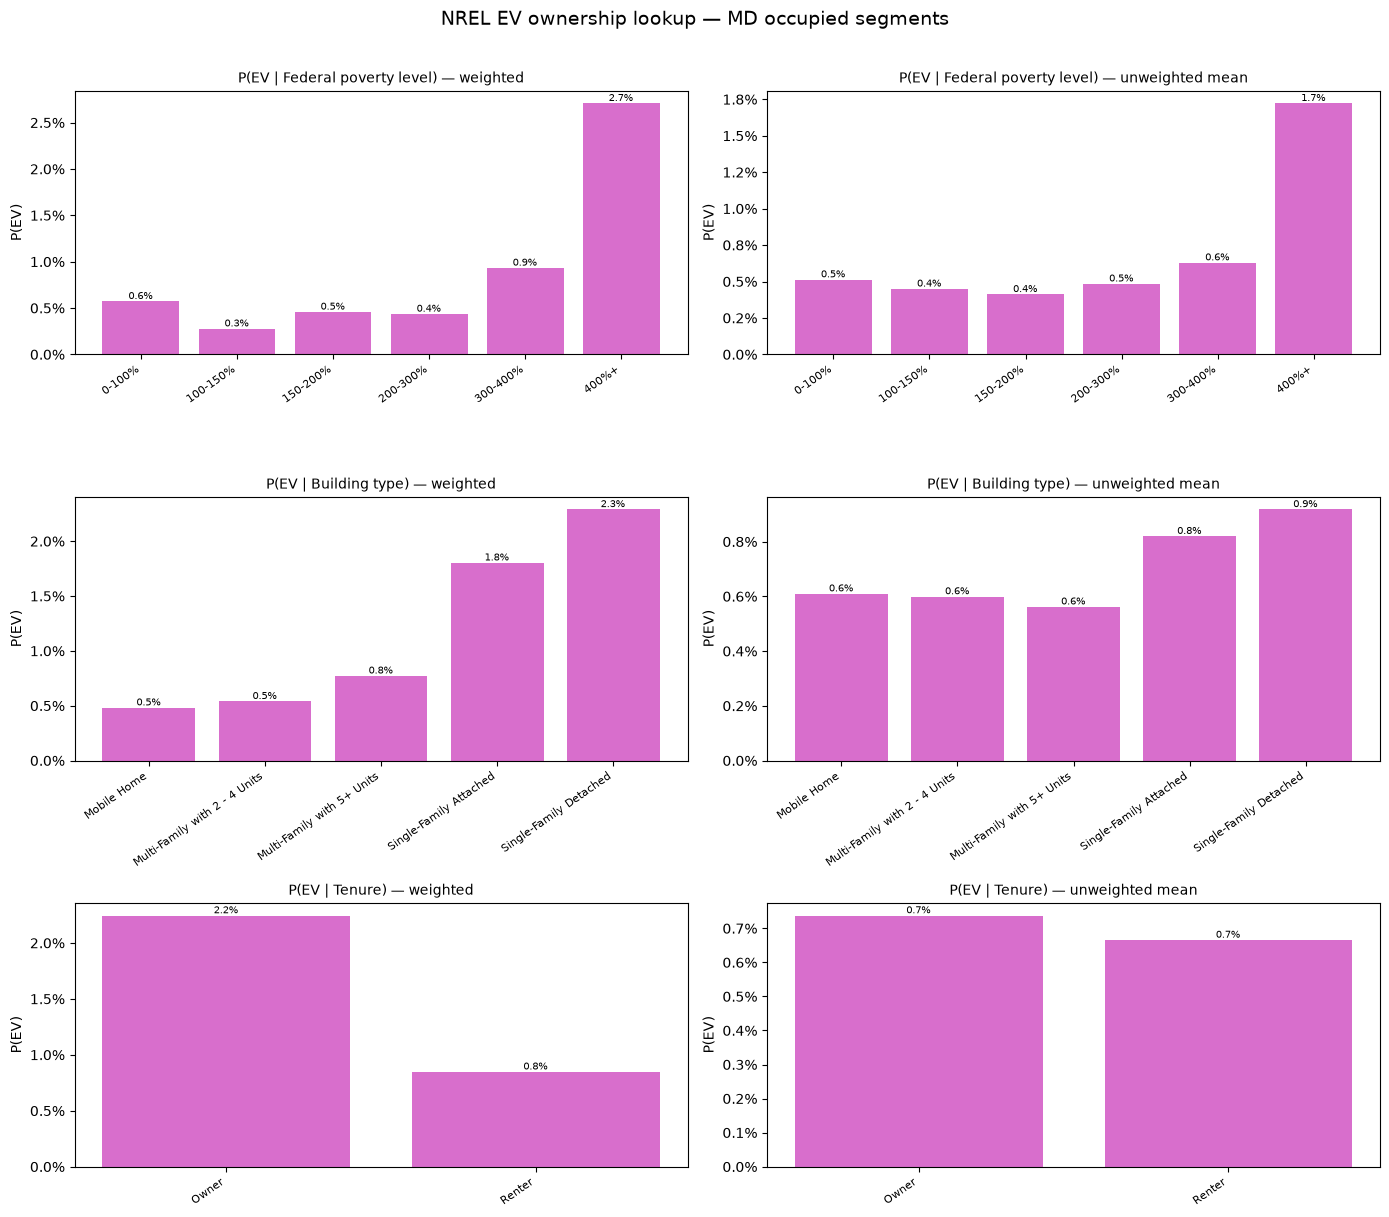

In [5]:
md_lookup_occupied = ev_lookup.filter(pl.col("tenure") != "Not Available")

print(
    f"P(EV) range: {md_lookup_occupied['ev_ownership_probability'].min():.4f}"
    f" – {md_lookup_occupied['ev_ownership_probability'].max():.4f}"
)

plot_ev_probs_by_category(
    md_lookup_occupied,
    weight_col="source_weight",
    title=f"NREL EV ownership lookup — {STATE} occupied segments",
    color="#D86ECC",
)


## 2. ResStock 2024 sample — joined P(EV) and Bernoulli draws

Join the same lookup onto MD ResStock buildings, then sample 0/1 EV ownership with
`EVAdoptionSampler` (same path as `ev_assignment: resstock_adoption` in the config).

ResStock 2024 metadata does not ship a realized `in.electric_vehicle_ownership` column
(that appears in the 2025 quota-sampled release), so “sampled” here is our Bernoulli draw
on the 2024 building stock.


In [6]:
sampler = EVAdoptionSampler(ev_ownership_df=ev_lookup, random_state=SEED)
bldg_ev = sampler.sample(metadata_df).with_columns(
    (pl.col("evs") == 1).alias("has_ev"),
)

occupied = bldg_ev.filter(~pl.col("is_vacant"))
print(f"Occupied buildings: {occupied.height:,}")
print(f"Mean P(EV) (occupied): {occupied['ev_ownership_probability'].mean():.4f}")
print(f"Expected EVs (sum P): {occupied['ev_ownership_probability'].sum():.1f}")
print(f"EVs sampled: {int(bldg_ev['evs'].sum()):,}")
print(f"Sample adoption rate (occupied): {occupied['has_ev'].mean():.4f}")


Occupied buildings: 9,001
Mean P(EV) (occupied): 0.0184
Expected EVs (sum P): 165.2
EVs sampled: 178
Sample adoption rate (occupied): 0.0198


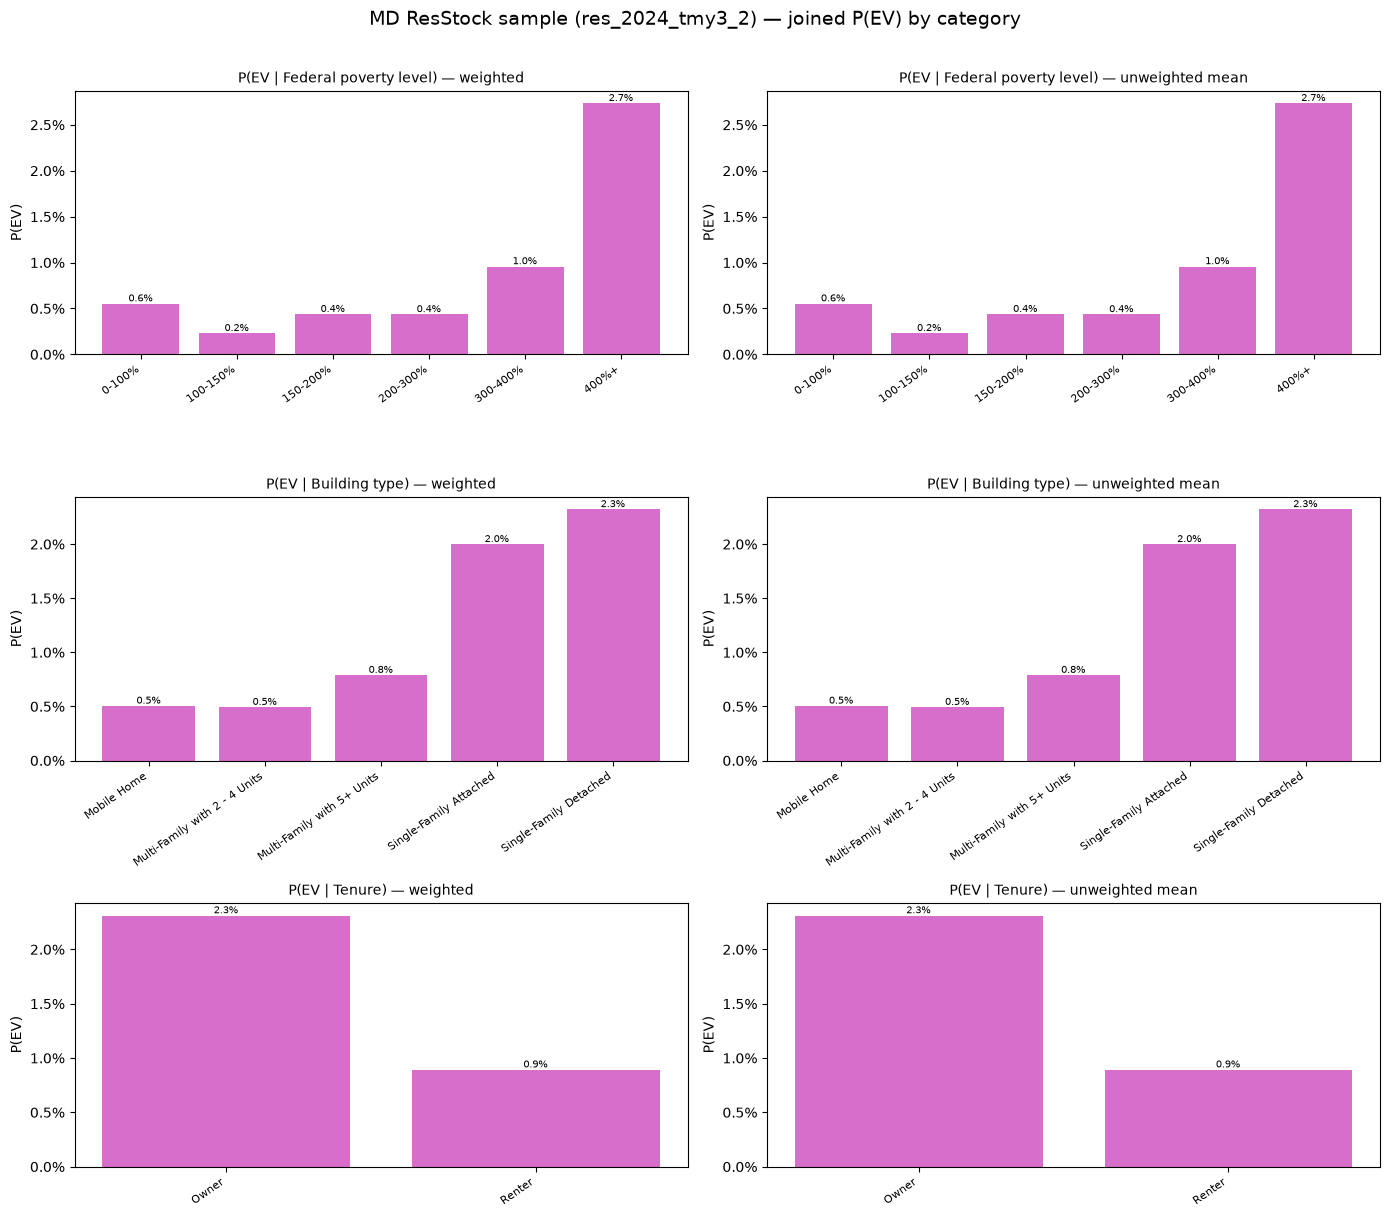

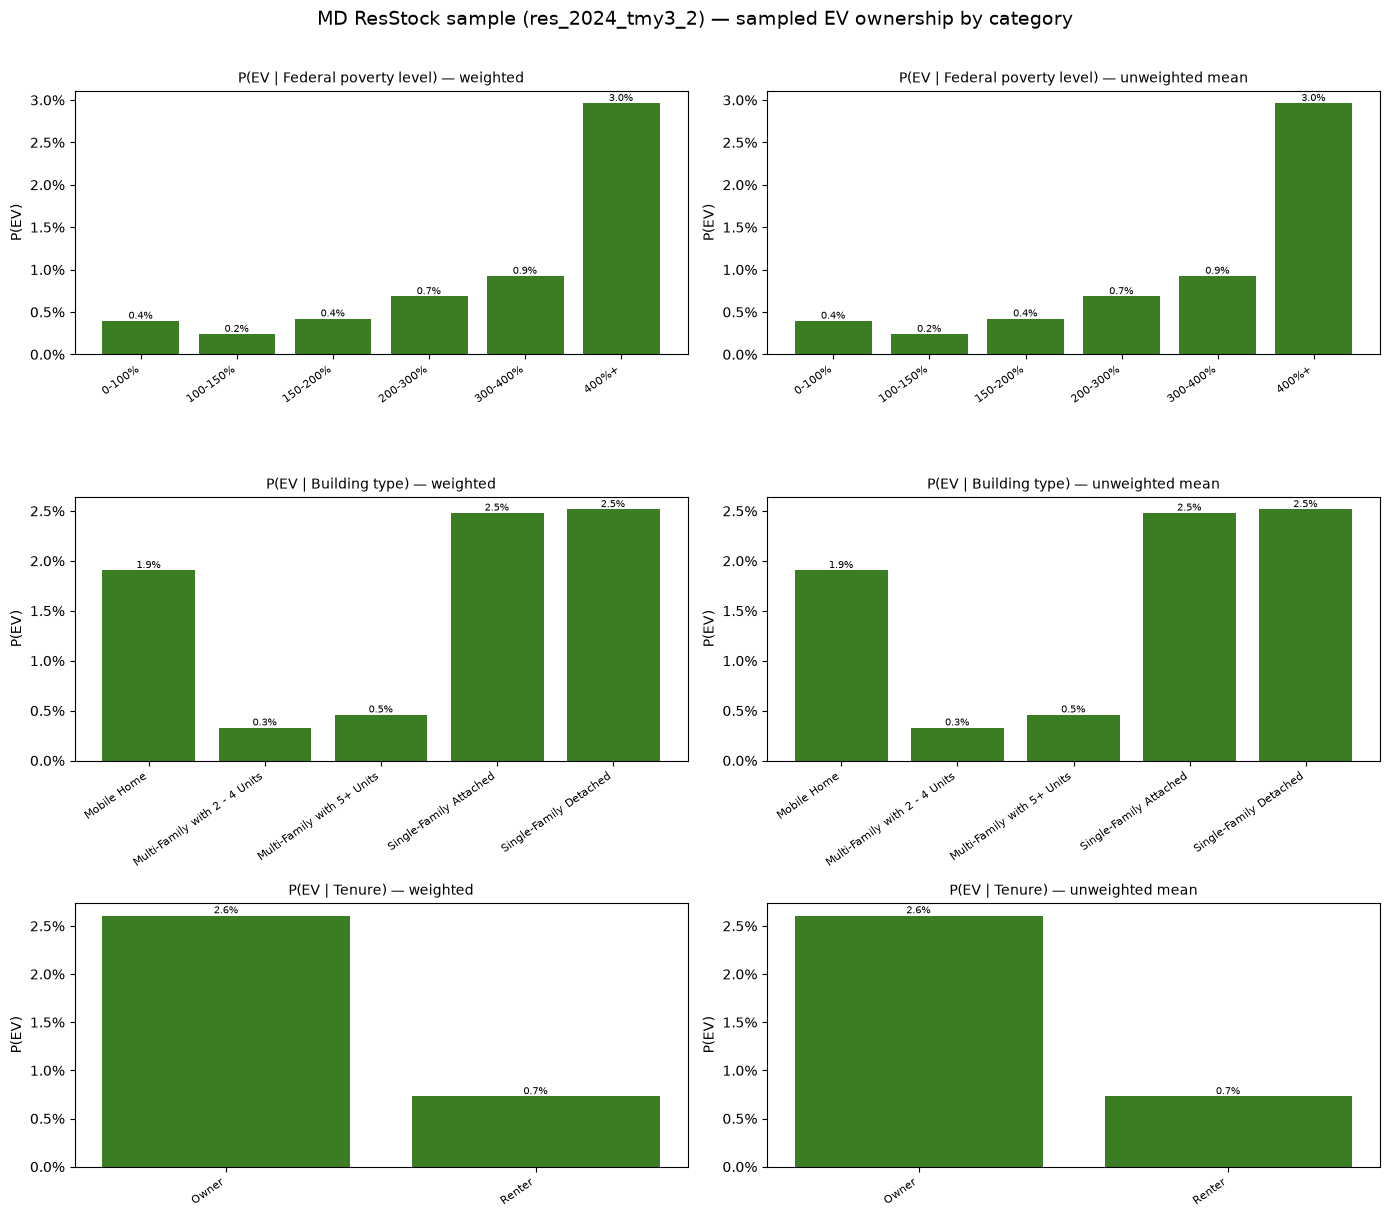

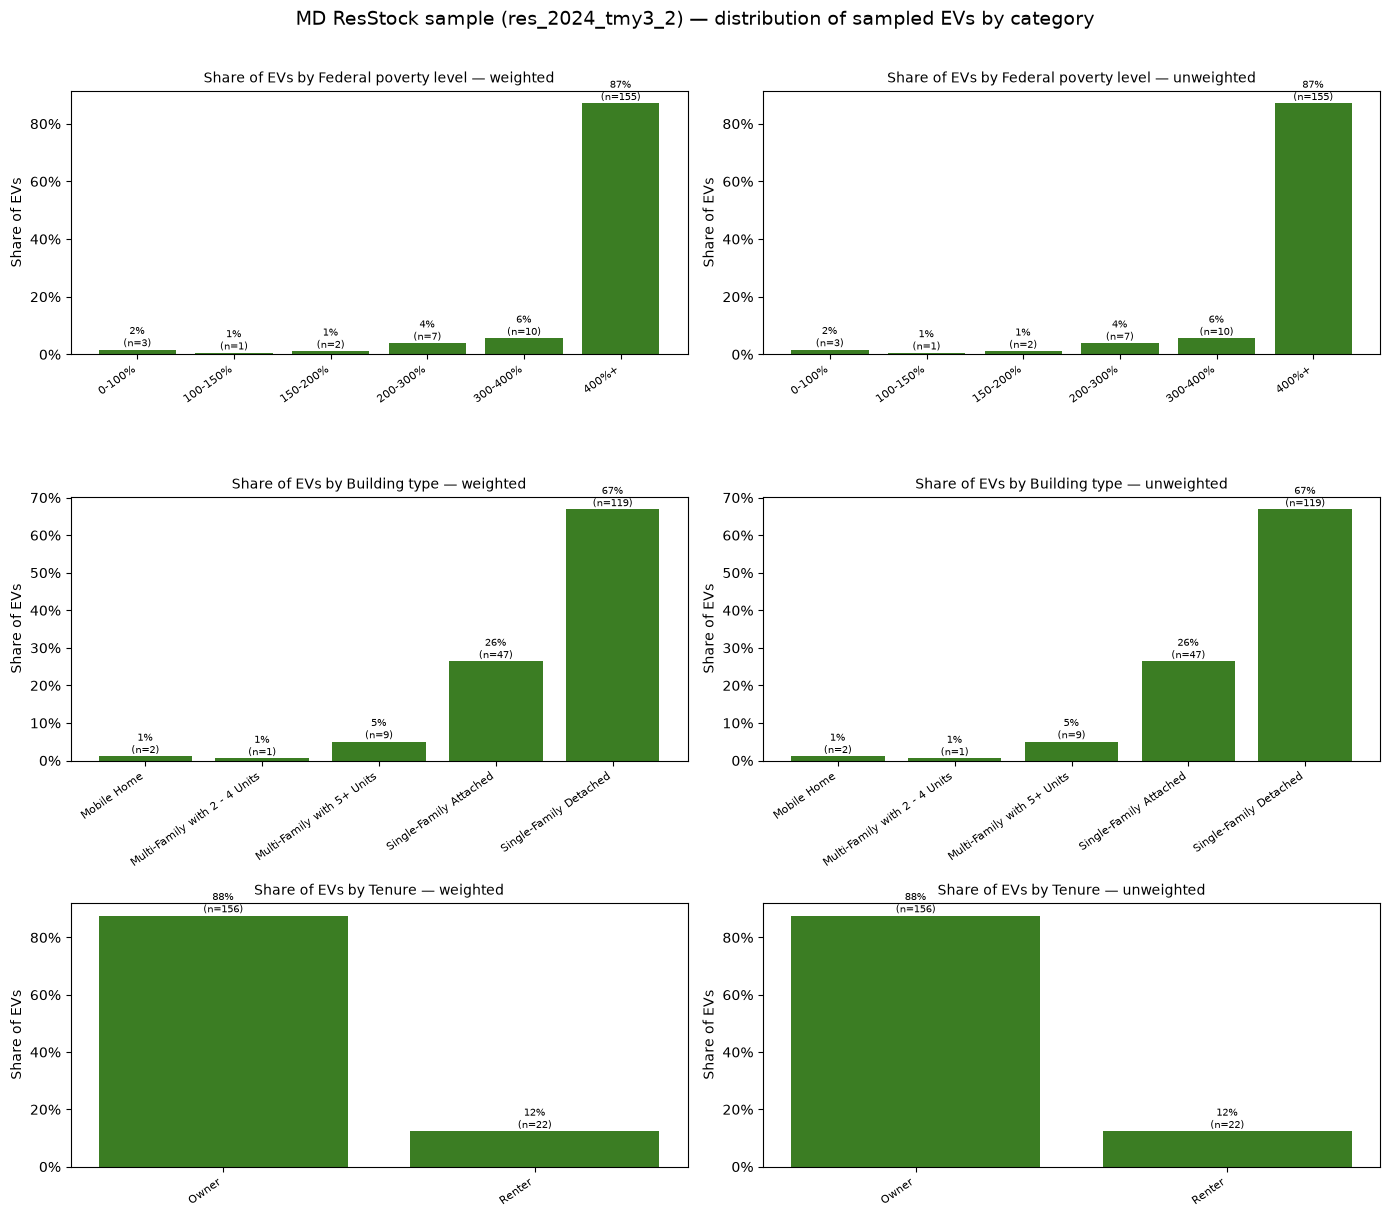

In [7]:
# Expected rates on the ResStock building mix (joined lookup P(EV))
plot_ev_probs_by_category(
    bldg_ev,
    weight_col="weight",
    prob_col="ev_ownership_probability",
    title=f"MD ResStock sample ({config.release}) — joined P(EV) by category",
    color="#D86ECC",
)

# Realized rates after Bernoulli sampling
plot_ev_probs_by_category(
    bldg_ev,
    weight_col="weight",
    prob_col="has_ev",
    title=f"MD ResStock sample ({config.release}) — sampled EV ownership by category",
    color="#3B7D23",
)

# Composition of the sampled EV fleet (share of EVs in each category)
plot_ev_distribution_by_category(
    bldg_ev,
    weight_col="weight",
    title=f"MD ResStock sample ({config.release}) — distribution of sampled EVs by category",
    color="#3B7D23",
)


### ResStock 2025 MD — NREL quota-sampled EV composition

ResStock **2025** ships `in.electric_vehicle_ownership` (quota sample). Load the MD upgrade-0
metadata and plot the same FPL / building type / tenure **fleet composition** for NREL’s
assigned EVs (pink), for comparison with our Bernoulli draws on the 2024 stock above.


ResStock 2025 metadata: /ebs/data/nrel/resstock/res_2025_amy2018_1/metadata/state=MD/upgrade=00/metadata.parquet
Occupied buildings: 8,954
NREL EVs (in.electric_vehicle_ownership=Yes): 127
Sample adoption rate (occupied): 0.0142


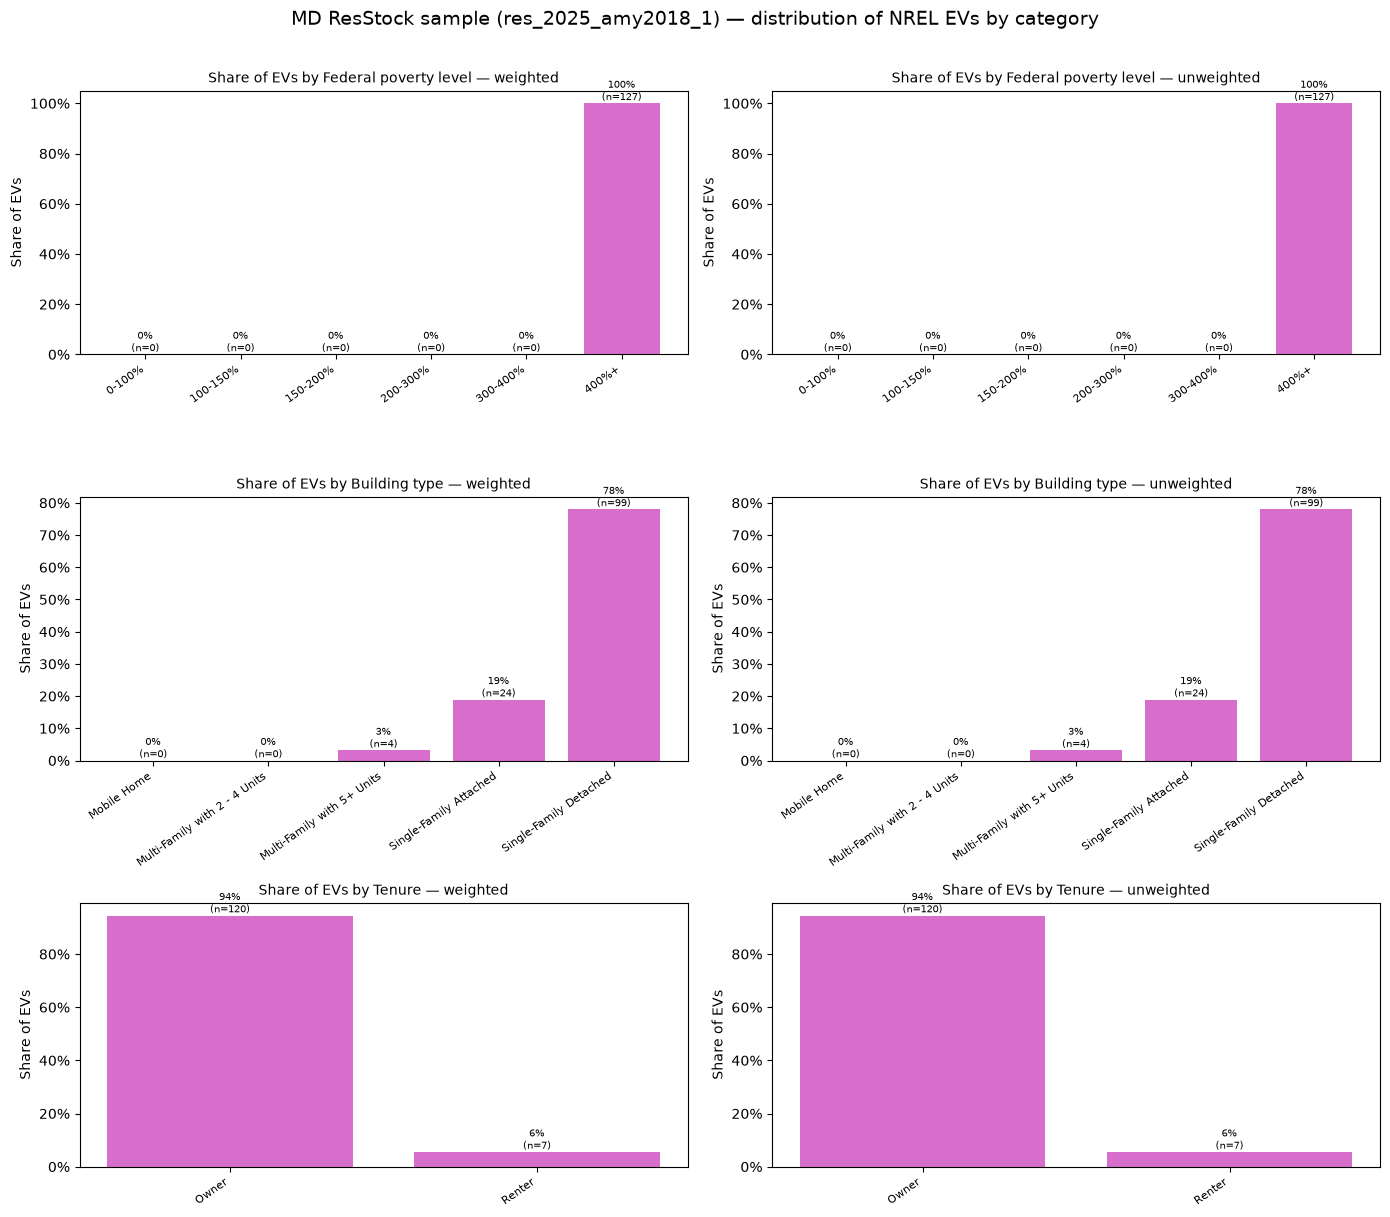

In [8]:
RELEASE_2025 = "res_2025_amy2018_1"
PATH_METADATA_2025 = (
    Path("/ebs/data/nrel/resstock")
    / RELEASE_2025
    / "metadata"
    / f"state={STATE}"
    / "upgrade=00"
    / "metadata.parquet"
)
print(f"ResStock 2025 metadata: {PATH_METADATA_2025}")

# Same category columns as 2024 via load_metadata; attach NREL's realized EV flag
metadata_2025 = load_metadata(str(PATH_METADATA_2025), STATE)
nrel_ev_flag = (
    pl.scan_parquet(PATH_METADATA_2025)
    .filter(pl.col("in.state") == STATE)
    .select(
        "bldg_id",
        (pl.col("in.electric_vehicle_ownership") == "Yes").alias("has_ev"),
    )
    .collect()
)
bldg_ev_2025 = metadata_2025.join(nrel_ev_flag, on="bldg_id", how="left")

occupied_2025 = bldg_ev_2025.filter(~pl.col("is_vacant"))
n_evs_2025 = int(bldg_ev_2025["has_ev"].sum())
print(f"Occupied buildings: {occupied_2025.height:,}")
print(f"NREL EVs (in.electric_vehicle_ownership=Yes): {n_evs_2025:,}")
print(f"Sample adoption rate (occupied): {occupied_2025['has_ev'].mean():.4f}")

plot_ev_distribution_by_category(
    bldg_ev_2025,
    weight_col="weight",
    title=f"MD ResStock sample ({RELEASE_2025}) — distribution of NREL EVs by category",
    color="#D86ECC",
)


In [9]:
def adoption_summary_table(df: pl.DataFrame, *group_cols: str) -> pl.DataFrame:
    """Tabular companion to the bar charts (occupied buildings only)."""
    return (
        df.filter(~pl.col("is_vacant"))
        .group_by(*group_cols)
        .agg(
            pl.len().alias("n_buildings"),
            pl.col("ev_ownership_probability").mean().round(4).alias("mean_p_ev"),
            pl.col("evs").sum().alias("n_evs_assigned"),
            (pl.col("evs").sum() / pl.len()).round(4).alias("sample_adoption_rate"),
        )
        .sort(*group_cols)
    )


for col, label in [("fpl", "FPL"), ("building_type", "building type"), ("tenure", "tenure")]:
    print(f"\nBy {label}")
    display(adoption_summary_table(bldg_ev, col))



By FPL


fpl,n_buildings,mean_p_ev,n_evs_assigned,sample_adoption_rate
str,u32,f64,i64,f64
"""0-100%""",762,0.0055,3,0.0039
"""100-150%""",420,0.0023,1,0.0024
"""150-200%""",476,0.0044,2,0.0042
"""200-300%""",1025,0.0043,7,0.0068
"""300-400%""",1083,0.0096,10,0.0092
"""400%+""",5235,0.0273,155,0.0296



By building type


building_type,n_buildings,mean_p_ev,n_evs_assigned,sample_adoption_rate
str,u32,f64,i64,f64
"""Mobile Home""",105,0.005,2,0.019
"""Multi-Family with 2 - 4 Units""",305,0.0049,1,0.0033
"""Multi-Family with 5+ Units""",1964,0.0079,9,0.0046
"""Single-Family Attached""",1895,0.02,47,0.0248
"""Single-Family Detached""",4732,0.0232,119,0.0251



By tenure


tenure,n_buildings,mean_p_ev,n_evs_assigned,sample_adoption_rate
str,u32,f64,i64,f64
"""Owner""",5983,0.0231,156,0.0261
"""Renter""",3018,0.0089,22,0.0073


## 3. NHTS vehicle-profile matching

Under `ev_assignment: resstock_adoption`, we do **not** match on vehicle count.
`load_nhts_data` / `load_metadata` already store income as three bins (≤$50k / $50–150k /
$150k+) and occupants as 1 / 2 / 3+. Weekday and weekend profiles are matched independently
with this cascade (urban/rural first; prefer occupants over income when dropping a dimension):

1. `urban_income_occupants` — urban/rural + income + occupants (**best / “exact” for this mode**)
2. `urban_occupants` — drop income, keep urban/rural + occupants
3. `urban_income` — drop occupants, keep urban/rural + income
4. `income_occupants` — drop urban/rural
5. `income` — income bucket only

If none of these tiers has enough profiles, matching raises an error rather than borrowing from another income bin.


In [10]:
nhts_df = load_nhts_data(config.nhts_path, STATE)
print(
    f"NHTS trips ({STATE} census division): {nhts_df.height:,}  "
    f"(percentile filter applied inside NHTSProfileSampler: "
    f"{config.nhts_daily_miles_percentile_low:.0f}–{config.nhts_daily_miles_percentile_high:.0f})"
)

nhts_sampler = NHTSProfileSampler(
    nhts_df=nhts_df,
    match_on_vehicles=False,  # resstock_adoption
    random_state=SEED,
    nhts_daily_miles_percentile_low=config.nhts_daily_miles_percentile_low,
    nhts_daily_miles_percentile_high=config.nhts_daily_miles_percentile_high,
)

# Only buildings with a sampled EV need a profile
bldg_vehicles = bldg_ev.filter(pl.col("evs") > 0).with_columns(pl.col("evs").alias("vehicles"))
print(f"Buildings with EV to match: {bldg_vehicles.height:,}")

vehicle_profiles, nhts_match_catalog = nhts_sampler.sample(bldg_vehicles, return_catalog=True)
print(f"Vehicle profiles sampled: {len(vehicle_profiles):,}")

print("\nMatch / trip-profile gaps")
display(summarize_nhts_match_catalog(nhts_match_catalog))


2026-07-28 20:23:56,067 - INFO - NHTS OUTOFTWN filter (keep 02=not away entire day): 3946/3979 trip rows retained
2026-07-28 20:23:56,071 - INFO - NHTS closed-home filter (start WHYFROM and end WHYTO in [1, 2]): 3512/3946 trip rows, 1180/1371 vehicles retained
2026-07-28 20:23:56,075 - INFO - NHTS daily-miles percentile filter [10.0, 90.0]: kept 944/1180 vehicles (miles band [4.0, 59.6]), 2819/3512 trip rows
2026-07-28 20:23:56,076 - INFO - Sampling vehicle profiles for 178 buildings...
2026-07-28 20:23:56,077 - INFO - Preparing NHTS weekday matching cache...
2026-07-28 20:23:56,080 - INFO - NHTS weekday cache prepared successfully
2026-07-28 20:23:56,081 - INFO - Preparing NHTS weekend matching cache...
2026-07-28 20:23:56,084 - INFO - NHTS weekend cache prepared successfully
2026-07-28 20:23:56,202 - INFO - Building progress: 178/178 (100.0%)
2026-07-28 20:23:56,203 - INFO - Generated 178 vehicle profiles from 178 buildings


NHTS trips (MD census division): 3,512  (percentile filter applied inside NHTSProfileSampler: 10–90)
Buildings with EV to match: 178
Vehicle profiles sampled: 178

Match / trip-profile gaps


metric,count,share_of_vehicle_slots
str,i64,f64
"""vehicle_slots""",178,1.0
"""missing_nhts_vehicle_match""",0,0.0
"""missing_weekday_trip_profile""",0,0.0
"""missing_weekend_trip_profile""",0,0.0
"""missing_both_trip_profiles""",0,0.0
"""vehicle_slots_with_any_gap""",0,0.0


In [11]:
# Tier order for resstock_adoption (match_on_vehicles=False)
MATCH_TIER_ORDER = {
    "urban_income_occupants": 1,
    "urban_occupants": 2,
    "urban_income": 3,
    "income_occupants": 4,
    "income": 5,
}
MATCH_TIER_LABEL = {
    1: "tier 1 — urban + income + occupants",
    2: "tier 2 — urban + occupants",
    3: "tier 3 — urban + income",
    4: "tier 4 — income + occupants",
    5: "tier 5 — income only",
}

match_tier_report = (
    nhts_match_catalog.with_columns(
        pl.col("weekday_match_type").replace_strict(MATCH_TIER_ORDER, default=7).alias("weekday_tier"),
        pl.col("weekend_match_type").replace_strict(MATCH_TIER_ORDER, default=7).alias("weekend_tier"),
    ).with_columns(
        pl.max_horizontal("weekday_tier", "weekend_tier").alias("max_tier"),
        ((pl.col("weekday_tier") == 1) & (pl.col("weekend_tier") == 1)).alias("both_days_exact"),
    )
)

n_slots = match_tier_report.height
n_both_exact = match_tier_report.filter(pl.col("both_days_exact")).height
n_any_fallback = match_tier_report.filter(pl.col("max_tier") > 1).height
print(f"EV slots: {n_slots:,}")
print(f"  Best tier on both weekday and weekend: {n_both_exact:,} ({n_both_exact / n_slots:.1%})")
print(f"  Any fallback (tier 2+ on at least one day): {n_any_fallback:,} ({n_any_fallback / n_slots:.1%})")


def match_type_table(col: str) -> pl.DataFrame:
    return (
        nhts_match_catalog.group_by(col)
        .agg(pl.len().alias("vehicle_slots"))
        .with_columns(
            pl.col(col).replace_strict(MATCH_TIER_ORDER, default=7).alias("tier"),
            (pl.col("vehicle_slots") / n_slots).round(4).alias("share_of_vehicle_slots"),
            pl.col(col)
            .replace_strict(MATCH_TIER_ORDER, default=7)
            .replace_strict(MATCH_TIER_LABEL)
            .alias("match_tier"),
        )
        .sort("tier")
        .select("match_tier", col, "vehicle_slots", "share_of_vehicle_slots")
    )


print("\nBy weekday match tier")
display(match_type_table("weekday_match_type"))

print("\nBy weekend match tier")
display(match_type_table("weekend_match_type"))

print("\nBy worst tier needed per slot (max of weekday / weekend)")
display(
    match_tier_report.group_by("max_tier")
    .agg(pl.len().alias("vehicle_slots"))
    .with_columns(
        (pl.col("vehicle_slots") / n_slots).round(4).alias("share_of_vehicle_slots"),
        pl.col("max_tier").replace_strict(MATCH_TIER_LABEL).alias("match_tier"),
    )
    .sort("max_tier")
    .select("match_tier", "max_tier", "vehicle_slots", "share_of_vehicle_slots")
)

print("\nWeekday × weekend match type")
display(
    nhts_match_catalog.group_by("weekday_match_type", "weekend_match_type")
    .agg(pl.len().alias("vehicle_slots"))
    .with_columns((pl.col("vehicle_slots") / n_slots).round(4).alias("share"))
    .sort("vehicle_slots", descending=True)
)


EV slots: 178
  Best tier on both weekday and weekend: 178 (100.0%)
  Any fallback (tier 2+ on at least one day): 0 (0.0%)

By weekday match tier


match_tier,weekday_match_type,vehicle_slots,share_of_vehicle_slots
str,str,u32,f64
"""tier 1 — urban + income + occu…","""urban_income_occupants""",178,1.0



By weekend match tier


match_tier,weekend_match_type,vehicle_slots,share_of_vehicle_slots
str,str,u32,f64
"""tier 1 — urban + income + occu…","""urban_income_occupants""",178,1.0



By worst tier needed per slot (max of weekday / weekend)


match_tier,max_tier,vehicle_slots,share_of_vehicle_slots
str,i64,u32,f64
"""tier 1 — urban + income + occu…",1,178,1.0



Weekday × weekend match type


weekday_match_type,weekend_match_type,vehicle_slots,share
str,str,u32,f64
"""urban_income_occupants""","""urban_income_occupants""",178,1.0


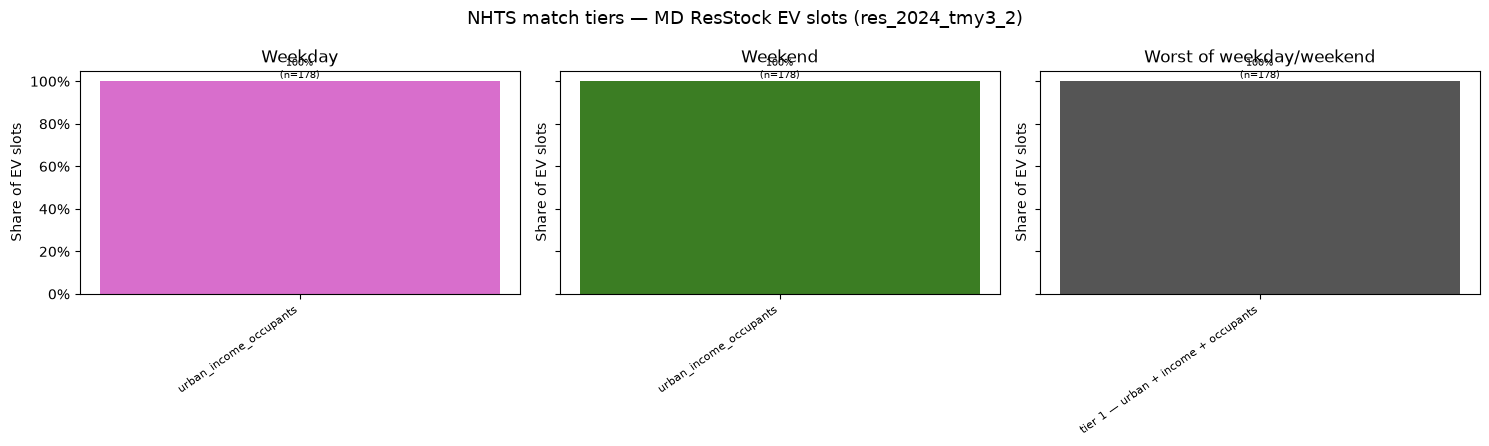

In [12]:
def _match_type_counts(col: str) -> pl.DataFrame:
    return (
        nhts_match_catalog.group_by(col)
        .agg(pl.len().alias("vehicle_slots"))
        .with_columns(
            pl.col(col).replace_strict(MATCH_TIER_ORDER, default=7).alias("tier"),
            (pl.col("vehicle_slots") / n_slots).alias("share"),
        )
        .sort("tier")
    )


weekday_counts = _match_type_counts("weekday_match_type")
weekend_counts = _match_type_counts("weekend_match_type")
worst_counts = (
    match_tier_report.group_by("max_tier")
    .agg(pl.len().alias("vehicle_slots"))
    .with_columns((pl.col("vehicle_slots") / n_slots).alias("share"))
    .sort("max_tier")
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
fig.suptitle(f"NHTS match tiers — {STATE} ResStock EV slots ({config.release})", fontsize=13)

panels = [
    (axes[0], weekday_counts, "weekday_match_type", "Weekday", COLOR_PINK),
    (axes[1], weekend_counts, "weekend_match_type", "Weekend", COLOR_GREEN),
    (axes[2], worst_counts, "max_tier", "Worst of weekday/weekend", "#555555"),
]
for ax, summary, label_col, title, color in panels:
    if label_col == "max_tier":
        labels = [MATCH_TIER_LABEL[t] for t in summary["max_tier"].to_list()]
    else:
        labels = summary[label_col].to_list()
    shares = summary["share"].to_numpy()
    x = range(len(labels))
    bars = ax.bar(x, shares, color=color)
    ax.set_title(title)
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("Share of EV slots")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    for bar, share, n in zip(bars, shares, summary["vehicle_slots"].to_list(), strict=False):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{share:.0%}\n(n={n})",
            ha="center",
            va="bottom",
            fontsize=7,
        )

fig.tight_layout()
plt.show()


## 4. How NHTS driving profiles differ

Stats on the **match pool** used by the sampler (same census division + daily-miles percentile
filter as the config). Each observation is one surveyed vehicle–day (weekday or weekend).


In [13]:
INCOME_LABELS = {
    1: "≤$50k",
    2: "$50–150k",
    3: "$150k+",
}
URBAN_LABELS = {1: "Urban", 2: "Rural"}

# Use the percentile-filtered pool the sampler actually matches against
nhts_pool = nhts_sampler.nhts_df
assert nhts_pool is not None

trip_cols = ["hh_vehicle_id", "vehicle_id", "weekday", "start_time", "end_time", "miles_driven"]
nhts_trips = nhts_pool.unique(subset=trip_cols)

vehicle_day = (
    nhts_trips.group_by("hh_vehicle_id", "vehicle_id", "weekday", "urban", "income_bucket", "occupants")
    .agg(
        pl.col("miles_driven").sum().alias("daily_miles"),
        pl.len().alias("n_trips"),
    )
    .with_columns(
        pl.when(pl.col("weekday") == 2).then(pl.lit("weekday")).otherwise(pl.lit("weekend")).alias("day_type"),
        pl.col("urban").replace_strict(URBAN_LABELS).alias("urban_label"),
        pl.col("income_bucket").replace_strict(INCOME_LABELS).alias("income_label"),
        pl.when(pl.col("occupants") >= 5)
        .then(pl.lit("5+"))
        .otherwise(pl.col("occupants").cast(pl.Utf8))
        .alias("occupants_bin"),
    )
)

print(f"NHTS vehicle-days in match pool: {vehicle_day.height:,}")
print(
    vehicle_day.group_by("day_type")
    .agg(
        pl.len().alias("n_vehicle_days"),
        pl.col("daily_miles").mean().round(1).alias("mean_miles"),
        pl.col("daily_miles").median().round(1).alias("median_miles"),
        pl.col("n_trips").mean().round(2).alias("mean_trips"),
    )
    .sort("day_type")
)


NHTS vehicle-days in match pool: 944
shape: (2, 5)
┌──────────┬────────────────┬────────────┬──────────────┬────────────┐
│ day_type ┆ n_vehicle_days ┆ mean_miles ┆ median_miles ┆ mean_trips │
│ ---      ┆ ---            ┆ ---        ┆ ---          ┆ ---        │
│ str      ┆ u32            ┆ f64        ┆ f64          ┆ f64        │
╞══════════╪════════════════╪════════════╪══════════════╪════════════╡
│ weekday  ┆ 746            ┆ 22.3       ┆ 18.9         ┆ 3.01       │
│ weekend  ┆ 198            ┆ 19.4       ┆ 15.5         ┆ 2.85       │
└──────────┴────────────────┴────────────┴──────────────┴────────────┘


In [14]:
def profile_summary(df: pl.DataFrame, *group_cols: str) -> pl.DataFrame:
    return (
        df.group_by(*group_cols)
        .agg(
            pl.len().alias("n_vehicle_days"),
            pl.col("daily_miles").mean().round(1).alias("mean_miles"),
            pl.col("daily_miles").median().round(1).alias("median_miles"),
            pl.col("daily_miles").quantile(0.90).round(1).alias("p90_miles"),
            pl.col("n_trips").mean().round(2).alias("mean_trips"),
        )
        .sort(*group_cols)
    )


print("By day type × urban/rural")
display(profile_summary(vehicle_day, "day_type", "urban_label"))

print("\nBy day type × income bucket")
display(profile_summary(vehicle_day, "day_type", "income_bucket", "income_label"))

print("\nBy day type × household size")
display(profile_summary(vehicle_day, "day_type", "occupants_bin"))


By day type × urban/rural


day_type,urban_label,n_vehicle_days,mean_miles,median_miles,p90_miles,mean_trips
str,str,u32,f64,f64,f64,f64
"""weekday""","""Rural""",144,26.8,24.7,46.4,2.69
"""weekday""","""Urban""",602,21.2,17.1,42.1,3.09
"""weekend""","""Rural""",32,22.1,19.7,39.8,2.53
"""weekend""","""Urban""",166,18.9,14.7,39.8,2.91



By day type × income bucket


day_type,income_bucket,income_label,n_vehicle_days,mean_miles,median_miles,p90_miles,mean_trips
str,i32,str,u32,f64,f64,f64,f64
"""weekday""",1,"""≤$50k""",143,21.0,17.6,40.0,2.83
"""weekday""",2,"""$50–150k""",441,23.6,20.9,44.6,3.06
"""weekday""",3,"""$150k+""",162,19.7,15.8,38.8,3.06
"""weekend""",1,"""≤$50k""",33,17.6,14.4,34.4,2.3
"""weekend""",2,"""$50–150k""",118,20.0,15.9,40.5,2.92
"""weekend""",3,"""$150k+""",47,19.3,15.4,32.9,3.06



By day type × household size


day_type,occupants_bin,n_vehicle_days,mean_miles,median_miles,p90_miles,mean_trips
str,str,u32,f64,f64,f64,f64
"""weekday""","""1""",130,21.0,17.4,38.2,3.03
"""weekday""","""2""",354,21.6,18.5,41.4,2.91
"""weekday""","""3""",262,23.7,19.9,47.7,3.15
"""weekend""","""1""",40,20.7,13.4,49.5,2.98
"""weekend""","""2""",86,19.2,15.4,39.8,2.94
"""weekend""","""3""",72,19.1,16.8,36.3,2.67


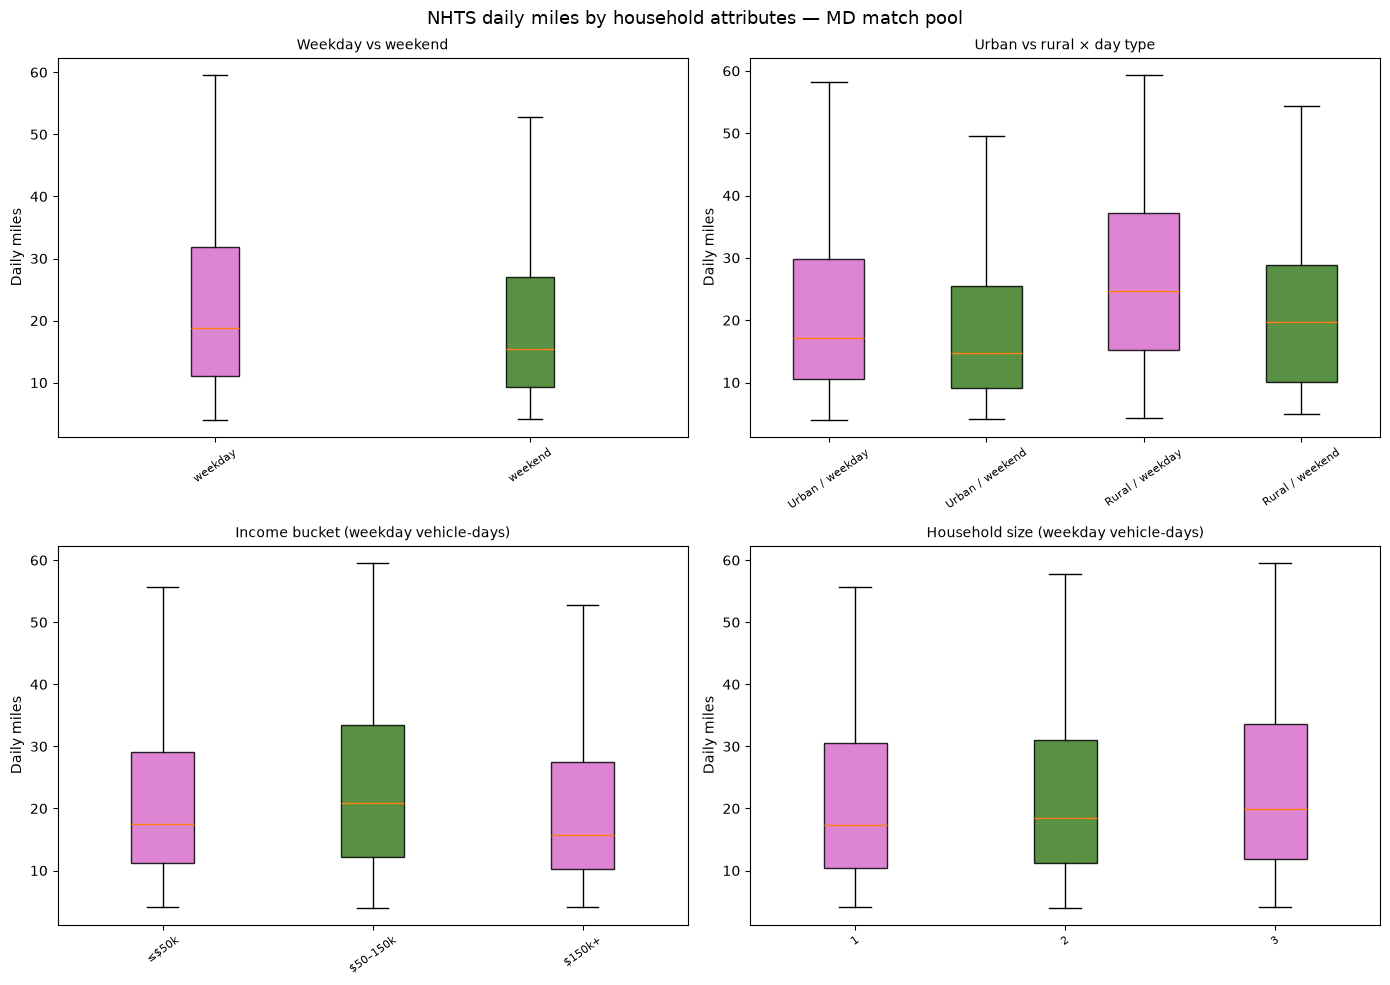

In [15]:
def _boxplot_by_group(
    ax,
    df: pl.DataFrame,
    group_col: str,
    *,
    order: list,
    title: str,
    ylabel: str = "Daily miles",
) -> None:
    labels = []
    data = []
    for g in order:
        vals = df.filter(pl.col(group_col) == g)["daily_miles"].to_numpy()
        if len(vals) == 0:
            continue
        labels.append(str(g))
        data.append(vals)
    bp = ax.boxplot(data, tick_labels=labels, showfliers=False, patch_artist=True)
    for i, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(COLOR_PINK if i % 2 == 0 else COLOR_GREEN)
        patch.set_alpha(0.85)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", labelrotation=35, labelsize=8)


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"NHTS daily miles by household attributes — {STATE} match pool", fontsize=13)

_boxplot_by_group(
    axes[0, 0],
    vehicle_day,
    "day_type",
    order=["weekday", "weekend"],
    title="Weekday vs weekend",
)

urban_plot = vehicle_day.with_columns(
    (pl.col("urban_label") + " / " + pl.col("day_type")).alias("urban_day")
)
_boxplot_by_group(
    axes[0, 1],
    urban_plot,
    "urban_day",
    order=["Urban / weekday", "Urban / weekend", "Rural / weekday", "Rural / weekend"],
    title="Urban vs rural × day type",
)

weekday_only = vehicle_day.filter(pl.col("day_type") == "weekday")
_boxplot_by_group(
    axes[1, 0],
    weekday_only,
    "income_label",
    order=[INCOME_LABELS[i] for i in range(1, 4)],
    title="Income bucket (weekday vehicle-days)",
)
_boxplot_by_group(
    axes[1, 1],
    weekday_only,
    "occupants_bin",
    order=["1", "2", "3", "4", "5+"],
    title="Household size (weekday vehicle-days)",
)

fig.tight_layout()
plt.show()


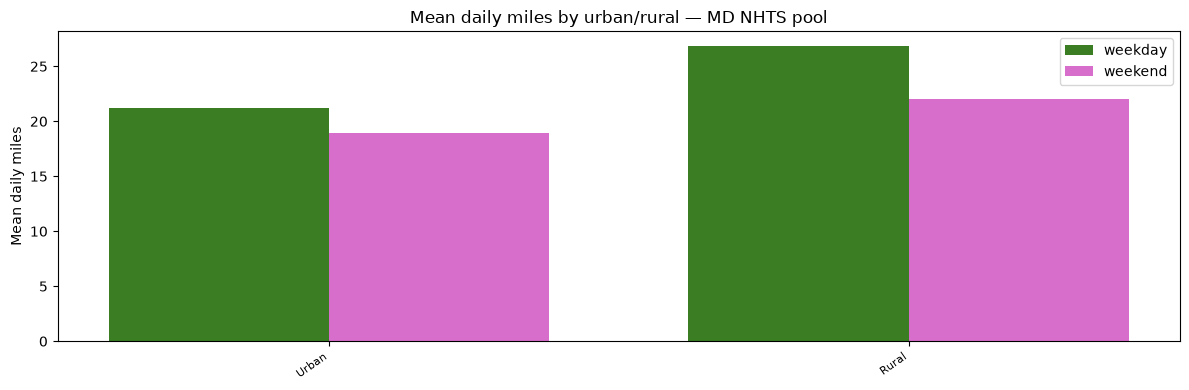

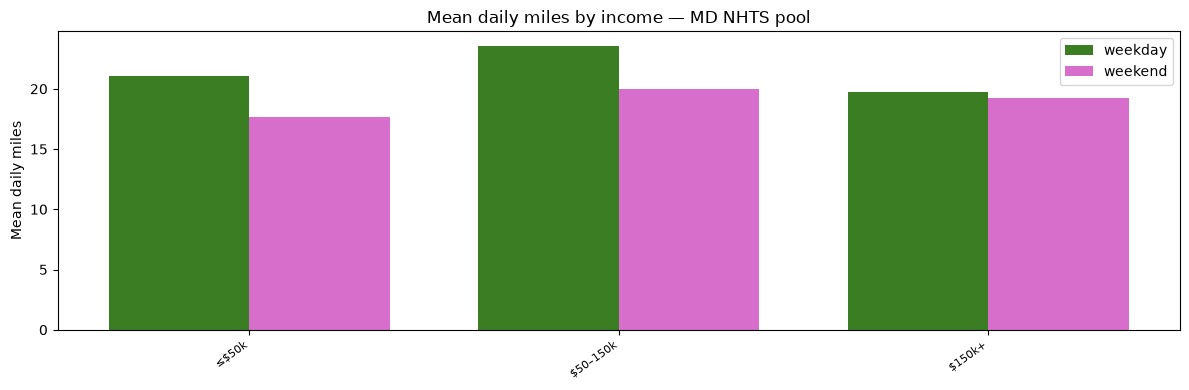

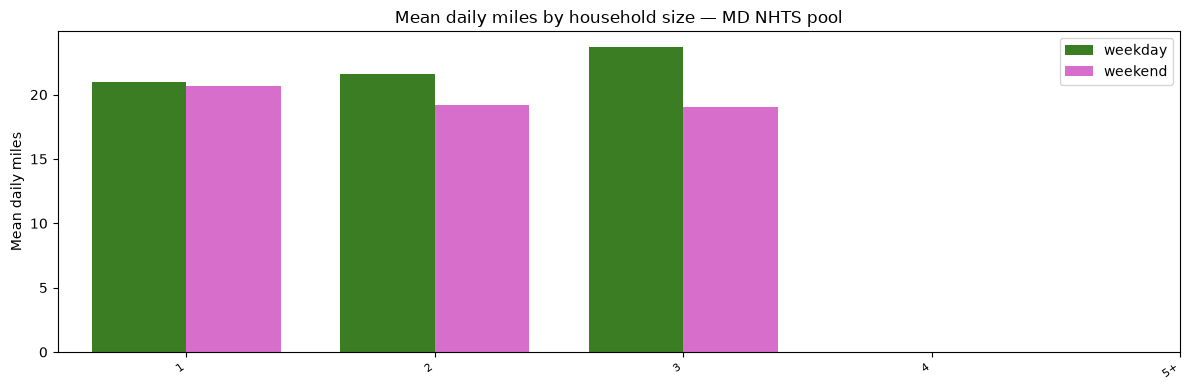

In [16]:
# Mean daily miles: weekday vs weekend side-by-side for each attribute
def _mean_miles_bars(df: pl.DataFrame, group_col: str, order: list[str], title: str) -> None:
    fig, ax = plt.subplots(figsize=(12, 4))
    width = 0.38
    x = np.arange(len(order))
    for i, (day, color) in enumerate([("weekday", COLOR_GREEN), ("weekend", COLOR_PINK)]):
        means = []
        for g in order:
            sub = df.filter((pl.col(group_col) == g) & (pl.col("day_type") == day))["daily_miles"]
            means.append(float(sub.mean()) if sub.len() else np.nan)
        ax.bar(x + (i - 0.5) * width, means, width=width, label=day, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("Mean daily miles")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.show()


_mean_miles_bars(
    vehicle_day,
    "urban_label",
    ["Urban", "Rural"],
    f"Mean daily miles by urban/rural — {STATE} NHTS pool",
)
_mean_miles_bars(
    vehicle_day,
    "income_label",
    [INCOME_LABELS[i] for i in range(1, 4)],
    f"Mean daily miles by income — {STATE} NHTS pool",
)
_mean_miles_bars(
    vehicle_day,
    "occupants_bin",
    ["1", "2", "3", "4", "5+"],
    f"Mean daily miles by household size — {STATE} NHTS pool",
)


2026-07-28 20:23:57,185 - INFO - Substituting symbol N from STIXNonUnicode
2026-07-28 20:23:57,242 - INFO - Substituting symbol N from STIXNonUnicode


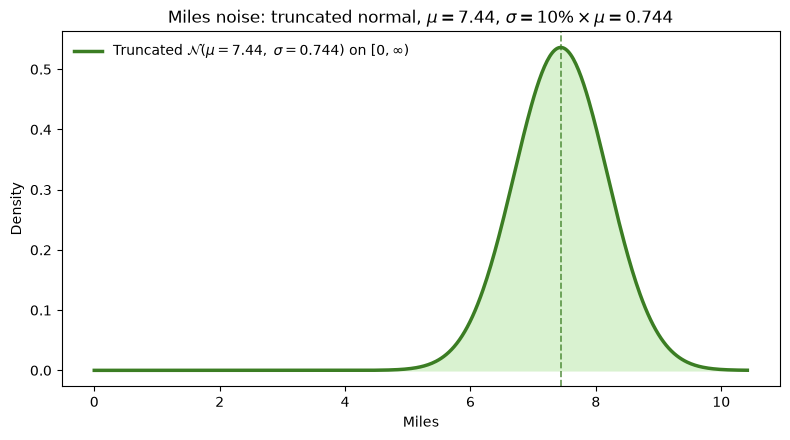

In [17]:
# Miles noise: truncated Normal(μ, 0.1·μ) on [0, ∞) — matches TripScheduleGenerator
from scipy.stats import truncnorm

mu = 7.44
sigma = 0.10 * mu  # 10% of mean
a, b = (0.0 - mu) / sigma, np.inf  # truncation bounds in standard units
x = np.linspace(0.0, mu + 4 * sigma, 500)
pdf = truncnorm.pdf(x, a, b, loc=mu, scale=sigma)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.fill_between(x, pdf, color="#D9F2D0", alpha=1.0)
ax.plot(
    x,
    pdf,
    color="#3B7D23",
    linewidth=2.5,
    label=rf"Truncated $\mathcal{{N}}(\mu={mu},\;\sigma={sigma:.3f})$ on $[0,\infty)$",
)
ax.axvline(mu, color="#3B7D23", linestyle="--", linewidth=1.2, alpha=0.8)
ax.set_xlabel("Miles")
ax.set_ylabel("Density")
ax.set_title(rf"Miles noise: truncated normal, $\mu = {mu}$, $\sigma = 10\% \times \mu = {sigma:.3f}$")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 5. Annual driving profiles

Replay each matched weekday / weekend NHTS template over the config simulation window
(`start_date` → `end_date`), applying the configured departure/arrival hour offsets and
miles noise (see the truncated-normal figure above). One row in `trip_schedules` is one trip.


In [18]:
assert config.start_date is not None and config.end_date is not None

trip_gen = TripScheduleGenerator(
    start_date=config.start_date,
    end_date=config.end_date,
    random_state=SEED,
    max_workers=config.max_workers,
    min_trip_away_hours=config.min_trip_away_hours,
    max_departure_hour=config.max_departure_hour,
    max_arrival_hour=config.max_arrival_hour,
    time_offsets=config.time_offsets,
    time_offset_probabilities=config.time_offset_probabilities,
    miles_noise_std_fraction=config.miles_noise_std_fraction,
)

print(
    f"Generating trips for {len(vehicle_profiles):,} vehicles "
    f"from {config.start_date} → {config.end_date} "
    f"(max_workers={config.max_workers})"
)
trip_schedules = trip_gen.generate(vehicle_profiles)
print(f"Trip schedule rows: {trip_schedules.height:,}")
display(trip_schedules.head(8))


Generating trips for 178 vehicles from 2024-01-01 04:00:00 → 2025-01-01 03:00:00 (max_workers=8)


2026-07-28 20:24:08,135 - INFO - Generating trip schedules: 178/178 (100.0%)
2026-07-28 20:24:08,137 - INFO - Generated 207796 trip schedules from 178 vehicle profiles


Trip schedule rows: 207,796


bldg_id,vehicle_id,travel_date,trip_departure_date,trip_departure_hour,trip_arrival_date,trip_arrival_hour,trip_miles_driven,tour_id,tour_departure_date,tour_departure_hour,tour_arrival_date,tour_arrival_hour
i64,i64,datetime[μs],datetime[μs],i64,datetime[μs],i64,f64,i64,datetime[μs],i64,datetime[μs],i64
3870,1,2024-01-01 00:00:00,2024-01-01 00:00:00,10,2024-01-01 00:00:00,11,2.492877,1,2024-01-01 00:00:00,10,2024-01-01 00:00:00,14
3870,1,2024-01-01 00:00:00,2024-01-01 00:00:00,12,2024-01-01 00:00:00,13,2.614527,1,2024-01-01 00:00:00,10,2024-01-01 00:00:00,14
3870,1,2024-01-01 00:00:00,2024-01-01 00:00:00,13,2024-01-01 00:00:00,14,0.633064,1,2024-01-01 00:00:00,10,2024-01-01 00:00:00,14
3870,1,2024-01-02 00:00:00,2024-01-02 00:00:00,10,2024-01-02 00:00:00,11,2.269697,1,2024-01-02 00:00:00,10,2024-01-02 00:00:00,13
3870,1,2024-01-02 00:00:00,2024-01-02 00:00:00,11,2024-01-02 00:00:00,12,0.528394,1,2024-01-02 00:00:00,10,2024-01-02 00:00:00,13
3870,1,2024-01-02 00:00:00,2024-01-02 00:00:00,12,2024-01-02 00:00:00,13,2.829527,1,2024-01-02 00:00:00,10,2024-01-02 00:00:00,13
3870,1,2024-01-03 00:00:00,2024-01-03 00:00:00,10,2024-01-03 00:00:00,11,2.03569,1,2024-01-03 00:00:00,10,2024-01-03 00:00:00,13
3870,1,2024-01-03 00:00:00,2024-01-03 00:00:00,11,2024-01-03 00:00:00,12,0.594464,1,2024-01-03 00:00:00,10,2024-01-03 00:00:00,13


In [19]:
# Per-vehicle and per-travel-day aggregates, joined to building attributes.
# daily_miles rows are travel days with ≥1 emitted trip (empty profile days omitted).
vehicle_attrs = bldg_vehicles.select(
    "bldg_id", "weight", "urban", "income_bucket", "occupants", "fpl", "building_type", "tenure"
)

n_sim_travel_days = len(
    list(
        iter_travel_day_starts(
            config.start_date,
            config.end_date,
            travel_day_start_hour=trip_gen.travel_day_start_hour,
        )
    )
)
print(f"Simulation travel days: {n_sim_travel_days:,}")

daily_miles = (
    trip_schedules.group_by("bldg_id", "vehicle_id", "date")
    .agg(
        pl.col("miles_driven").sum().alias("daily_miles"),
        pl.len().alias("n_trips"),
    )
    .with_columns(
        pl.col("date").dt.weekday().alias("iso_weekday"),  # Mon=1 … Sun=7
        pl.col("date").dt.month().alias("month"),
    )
    .with_columns(
        pl.when(pl.col("iso_weekday") <= 5)
        .then(pl.lit("weekday"))
        .otherwise(pl.lit("weekend"))
        .alias("day_type"),
    )
    .join(vehicle_attrs, on="bldg_id", how="left")
    .with_columns(
        pl.col("urban").replace_strict(URBAN_LABELS).alias("urban_label"),
        pl.col("income_bucket").replace_strict(INCOME_LABELS).alias("income_label"),
    )
)

annual_miles = (
    daily_miles.group_by("bldg_id", "vehicle_id")
    .agg(
        pl.col("daily_miles").sum().alias("annual_miles"),
        pl.col("daily_miles").mean().alias("mean_daily_miles_on_drive_days"),
        pl.col("daily_miles").median().alias("median_daily_miles_on_drive_days"),
        pl.col("daily_miles").max().alias("max_daily_miles"),
        pl.col("n_trips").sum().alias("annual_trips"),
        pl.len().alias("n_drive_days"),
    )
    .with_columns(
        (pl.col("annual_miles") / n_sim_travel_days).alias("mean_daily_miles"),
    )
    .join(vehicle_attrs, on="bldg_id", how="left")
    .with_columns(
        pl.col("urban").replace_strict(URBAN_LABELS).alias("urban_label"),
        pl.col("income_bucket").replace_strict(INCOME_LABELS).alias("income_label"),
    )
)

print(f"Vehicles with ≥1 trip: {annual_miles.height:,} / {len(vehicle_profiles):,}")
print(f"Drive-day rows: {daily_miles.height:,}")
display(
    annual_miles.select(
        "annual_miles",
        "mean_daily_miles",
        "mean_daily_miles_on_drive_days",
        "max_daily_miles",
        "annual_trips",
        "n_drive_days",
    ).describe()
)


Simulation travel days: 366


ColumnNotFoundError: unable to find column "date"; valid columns: ["bldg_id", "vehicle_id", "travel_date", "trip_departure_date", "trip_departure_hour", "trip_arrival_date", "trip_arrival_hour", "trip_miles_driven", "tour_id", "tour_departure_date", "tour_departure_hour", "tour_arrival_date", "tour_arrival_hour"]

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'sink' <---
DF ["bldg_id", "vehicle_id", "travel_date", "trip_departure_date", ...]; PROJECT */13 COLUMNS

In [ ]:
def _summary_row(name: str, values: pl.Series) -> dict:
    arr = values.drop_nulls().to_numpy()
    return {
        "group": name,
        "n": len(arr),
        "mean": round(float(arr.mean()), 1) if len(arr) else None,
        "median": round(float(np.median(arr)), 1) if len(arr) else None,
        "p10": round(float(np.percentile(arr, 10)), 1) if len(arr) else None,
        "p90": round(float(np.percentile(arr, 90)), 1) if len(arr) else None,
    }


print("Annual miles per vehicle")
display(pl.DataFrame([_summary_row("all EV slots", annual_miles["annual_miles"])]))

print("\nAnnual miles by urban/rural")
display(
    pl.DataFrame([
        _summary_row(label, annual_miles.filter(pl.col("urban_label") == label)["annual_miles"])
        for label in ["Urban", "Rural"]
    ])
)

print("\nMean daily miles by day type")
display(
    daily_miles.group_by("day_type")
    .agg(
        pl.len().alias("n_vehicle_days"),
        pl.col("daily_miles").mean().round(1).alias("mean_miles"),
        pl.col("daily_miles").median().round(1).alias("median_miles"),
        pl.col("n_trips").mean().round(2).alias("mean_trips"),
    )
    .sort("day_type")
)

print("\nMean daily miles by urban/rural × day type")
display(
    daily_miles.group_by("urban_label", "day_type")
    .agg(
        pl.len().alias("n_vehicle_days"),
        pl.col("daily_miles").mean().round(1).alias("mean_miles"),
        pl.col("daily_miles").median().round(1).alias("median_miles"),
    )
    .sort("urban_label", "day_type")
)

print("\nMean daily miles by month")
display(
    daily_miles.group_by("month")
    .agg(
        pl.col("daily_miles").mean().round(1).alias("mean_miles"),
        pl.col("daily_miles").median().round(1).alias("median_miles"),
        pl.len().alias("n_vehicle_days"),
    )
    .sort("month")
)


Annual miles per vehicle


group,n,mean,median,p10,p90
str,i64,f64,f64,f64,f64
"""all EV slots""",178,9874.3,9069.3,3444.8,17248.7



Annual miles by urban/rural


group,n,mean,median,p10,p90
str,i64,f64,f64,f64,f64
"""Urban""",174,9684.4,8813.2,3415.1,16934.0
"""Rural""",4,18134.4,16048.7,14575.1,23362.4



Mean daily miles by day type


day_type,n_vehicle_days,mean_miles,median_miles,mean_trips
str,u32,f64,f64,f64
"""weekday""",46636,26.6,20.6,3.87
"""weekend""",18512,27.9,20.5,4.14



Mean daily miles by urban/rural × day type


urban_label,day_type,n_vehicle_days,mean_miles,median_miles
str,str,u32,f64,f64
"""Rural""","""weekday""",1048,43.9,42.2
"""Rural""","""weekend""",416,63.8,78.9
"""Urban""","""weekday""",45588,26.2,20.2
"""Urban""","""weekend""",18096,27.1,20.2



Mean daily miles by month


month,mean_miles,median_miles,n_vehicle_days
i8,f64,f64,u32
1,26.9,20.6,5518
2,27.0,20.7,5162
3,27.0,20.6,5518
4,26.9,20.6,5340
5,26.9,20.6,5518
…,…,…,…
8,27.0,20.5,5518
9,27.0,20.5,5340
10,27.0,20.6,5518


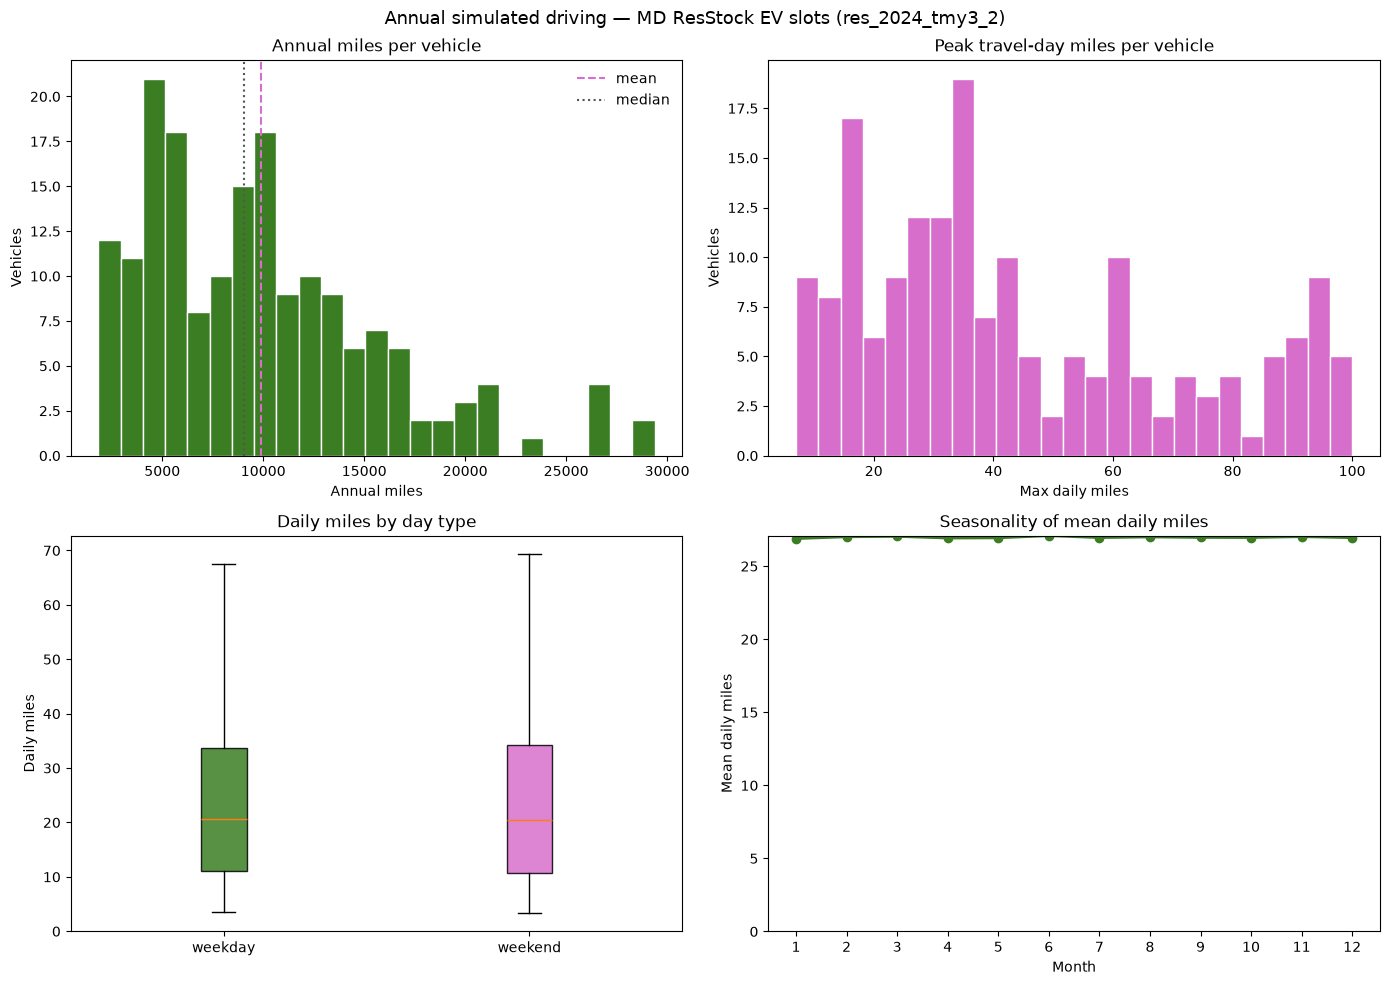

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Annual simulated driving — {STATE} ResStock EV slots ({config.release})", fontsize=13)

# Annual miles histogram
ax = axes[0, 0]
ax.hist(annual_miles["annual_miles"].to_numpy(), bins=25, color=COLOR_GREEN, edgecolor="white")
ax.axvline(annual_miles["annual_miles"].mean(), color=COLOR_PINK, linestyle="--", linewidth=1.5, label="mean")
ax.axvline(annual_miles["annual_miles"].median(), color="#555555", linestyle=":", linewidth=1.5, label="median")
ax.set_xlabel("Annual miles")
ax.set_ylabel("Vehicles")
ax.set_title("Annual miles per vehicle")
ax.legend(frameon=False)

# Max daily miles (battery-sizing relevant)
ax = axes[0, 1]
ax.hist(annual_miles["max_daily_miles"].to_numpy(), bins=25, color=COLOR_PINK, edgecolor="white")
ax.set_xlabel("Max daily miles")
ax.set_ylabel("Vehicles")
ax.set_title("Peak travel-day miles per vehicle")

# Daily miles: weekday vs weekend boxplots
ax = axes[1, 0]
box_data = [
    daily_miles.filter(pl.col("day_type") == d)["daily_miles"].to_numpy()
    for d in ["weekday", "weekend"]
]
bp = ax.boxplot(box_data, tick_labels=["weekday", "weekend"], showfliers=False, patch_artist=True)
for patch, color in zip(bp["boxes"], [COLOR_GREEN, COLOR_PINK]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
ax.set_ylabel("Daily miles")
ax.set_title("Daily miles by day type")

# Mean daily miles by month
ax = axes[1, 1]
monthly = (
    daily_miles.group_by("month")
    .agg(pl.col("daily_miles").mean().alias("mean_miles"))
    .sort("month")
)
ax.plot(monthly["month"].to_numpy(), monthly["mean_miles"].to_numpy(), color=COLOR_GREEN, marker="o", linewidth=2)
ax.set_xticks(range(1, 13))
ax.set_xlabel("Month")
ax.set_ylabel("Mean daily miles")
ax.set_title("Seasonality of mean daily miles")
ax.set_ylim(bottom=0)

fig.tight_layout()
plt.show()


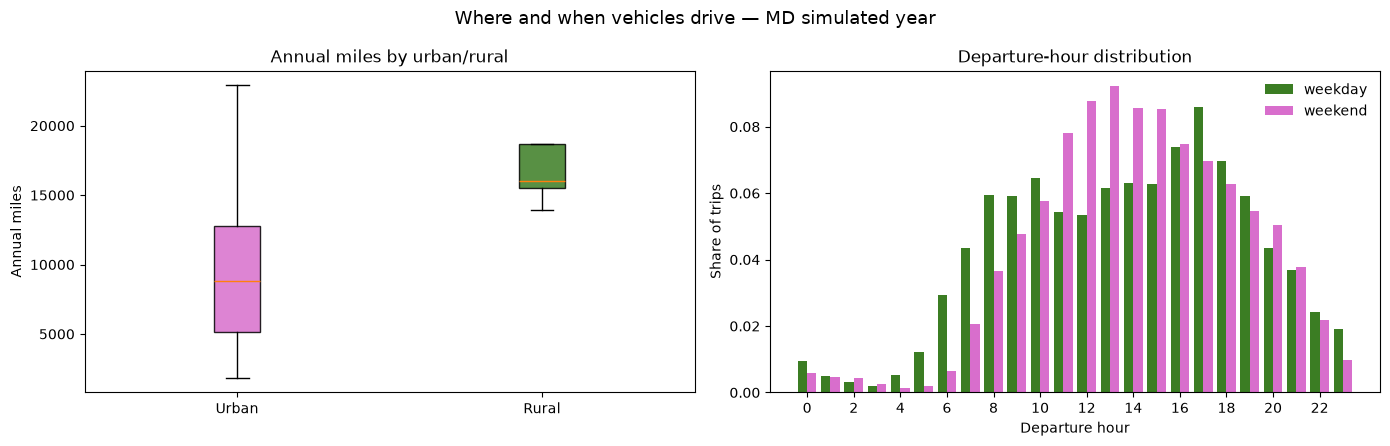

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle(f"Where and when vehicles drive — {STATE} simulated year", fontsize=13)

# Annual miles by urban/rural
ax = axes[0]
urban_order = ["Urban", "Rural"]
box_data = [
    annual_miles.filter(pl.col("urban_label") == g)["annual_miles"].to_numpy()
    for g in urban_order
]
bp = ax.boxplot(box_data, tick_labels=urban_order, showfliers=False, patch_artist=True)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(COLOR_PINK if i % 2 == 0 else COLOR_GREEN)
    patch.set_alpha(0.85)
ax.set_ylabel("Annual miles")
ax.set_title("Annual miles by urban/rural")

# Departure-hour distribution (weekday vs weekend)
ax = axes[1]
trips_with_day = trip_schedules.with_columns(
    pl.when(pl.col("date").dt.weekday() <= 5)
    .then(pl.lit("weekday"))
    .otherwise(pl.lit("weekend"))
    .alias("day_type")
)
hours = np.arange(24)
width = 0.4
for i, (day, color) in enumerate([("weekday", COLOR_GREEN), ("weekend", COLOR_PINK)]):
    counts = (
        trips_with_day.filter(pl.col("day_type") == day)
        .group_by("departure_hour")
        .agg(pl.len().alias("n"))
        .sort("departure_hour")
    )
    count_map = dict(zip(counts["departure_hour"].to_list(), counts["n"].to_list()))
    vals = np.array([count_map.get(h, 0) for h in hours], dtype=float)
    vals = vals / vals.sum() if vals.sum() else vals
    ax.bar(hours + (i - 0.5) * width, vals, width=width, label=day, color=color)
ax.set_xlabel("Departure hour")
ax.set_ylabel("Share of trips")
ax.set_title("Departure-hour distribution")
ax.set_xticks(range(0, 24, 2))
ax.legend(frameon=False)

fig.tight_layout()
plt.show()


### ResStock 2025 MD — same NHTS driving pipeline on NREL EVs

Reuse the fitted `NHTSProfileSampler` / `TripScheduleGenerator` on buildings with
`in.electric_vehicle_ownership == Yes` (127 MD EVs), then plot the same annual-miles
and departure-hour figures as above.


In [ ]:
# Same match + annual replay path as §3/§5, on NREL's 2025 quota-sampled EV owners
bldg_vehicles_2025 = bldg_ev_2025.filter(pl.col("has_ev")).with_columns(pl.lit(1).alias("vehicles"))
print(f"2025 NREL EV buildings to match: {bldg_vehicles_2025.height:,}")

vehicle_profiles_2025, nhts_match_catalog_2025 = nhts_sampler.sample(
    bldg_vehicles_2025, return_catalog=True
)
print(f"Vehicle profiles sampled: {len(vehicle_profiles_2025):,}")
print("\nMatch / trip-profile gaps (2025)")
display(summarize_nhts_match_catalog(nhts_match_catalog_2025))

trip_schedules_2025 = trip_gen.generate(vehicle_profiles_2025)
print(f"Trip schedule rows: {trip_schedules_2025.height:,}")

vehicle_attrs_2025 = bldg_vehicles_2025.select(
    "bldg_id", "weight", "urban", "income_bucket", "occupants", "fpl", "building_type", "tenure"
)

daily_miles_2025 = (
    trip_schedules_2025.group_by("bldg_id", "vehicle_id", "date")
    .agg(
        pl.col("miles_driven").sum().alias("daily_miles"),
        pl.len().alias("n_trips"),
    )
    .with_columns(
        pl.col("date").dt.weekday().alias("iso_weekday"),
        pl.col("date").dt.month().alias("month"),
    )
    .with_columns(
        pl.when(pl.col("iso_weekday") <= 5)
        .then(pl.lit("weekday"))
        .otherwise(pl.lit("weekend"))
        .alias("day_type"),
    )
    .join(vehicle_attrs_2025, on="bldg_id", how="left")
    .with_columns(
        pl.col("urban").replace_strict(URBAN_LABELS).alias("urban_label"),
        pl.col("income_bucket").replace_strict(INCOME_LABELS).alias("income_label"),
    )
)

annual_miles_2025 = (
    daily_miles_2025.group_by("bldg_id", "vehicle_id")
    .agg(
        pl.col("daily_miles").sum().alias("annual_miles"),
        pl.col("daily_miles").mean().alias("mean_daily_miles_on_drive_days"),
        pl.col("daily_miles").median().alias("median_daily_miles_on_drive_days"),
        pl.col("daily_miles").max().alias("max_daily_miles"),
        pl.col("n_trips").sum().alias("annual_trips"),
        pl.len().alias("n_drive_days"),
    )
    .with_columns(
        (pl.col("annual_miles") / n_sim_travel_days).alias("mean_daily_miles"),
    )
    .join(vehicle_attrs_2025, on="bldg_id", how="left")
    .with_columns(
        pl.col("urban").replace_strict(URBAN_LABELS).alias("urban_label"),
        pl.col("income_bucket").replace_strict(INCOME_LABELS).alias("income_label"),
    )
)

print(f"Vehicles with ≥1 trip: {annual_miles_2025.height:,} / {len(vehicle_profiles_2025):,}")
print(f"Drive-day rows: {daily_miles_2025.height:,}")
display(
    annual_miles_2025.select(
        "annual_miles",
        "mean_daily_miles",
        "mean_daily_miles_on_drive_days",
        "max_daily_miles",
        "annual_trips",
        "n_drive_days",
    ).describe()
)


2026-07-24 18:03:32,009 - INFO - Sampling vehicle profiles for 127 buildings...
2026-07-24 18:03:32,203 - INFO - Building progress: 127/127 (100.0%)
2026-07-24 18:03:32,203 - INFO - Generated 127 vehicle profiles from 127 buildings


2025 NREL EV buildings to match: 127
Vehicle profiles sampled: 127

Match / trip-profile gaps (2025)


metric,count,share_of_vehicle_slots
str,i64,f64
"""vehicle_slots""",127,1.0
"""missing_nhts_vehicle_match""",0,0.0
"""missing_weekday_trip_profile""",0,0.0
"""missing_weekend_trip_profile""",0,0.0
"""missing_both_trip_profiles""",0,0.0
"""vehicle_slots_with_any_gap""",0,0.0


2026-07-24 18:03:41,909 - INFO - Generating trip schedules: 127/127 (100.0%)
2026-07-24 18:03:41,912 - INFO - Generated 190863 trip schedules from 127 vehicle profiles


Trip schedule rows: 190,863
Vehicles with ≥1 trip: 127 / 127
Drive-day rows: 46,482


statistic,annual_miles,mean_daily_miles,mean_daily_miles_on_drive_days,max_daily_miles,annual_trips,n_drive_days
str,f64,f64,f64,f64,f64,f64
"""count""",127.0,127.0,127.0,127.0,127.0,127.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",10746.650028,29.362432,29.362432,46.798437,1502.858268,366.0
"""std""",6084.252025,16.623639,16.623639,25.604585,716.155052,0.0
"""min""",2032.036775,5.552013,5.552013,9.490321,470.0,366.0
"""25%""",6350.622049,17.351426,17.351426,28.778569,940.0,366.0
"""50%""",9383.82757,25.638873,25.638873,40.620798,1356.0,366.0
"""75%""",13324.095733,36.404633,36.404633,67.40925,1884.0,366.0
"""max""",32308.79815,88.275405,88.275405,112.101493,4904.0,366.0


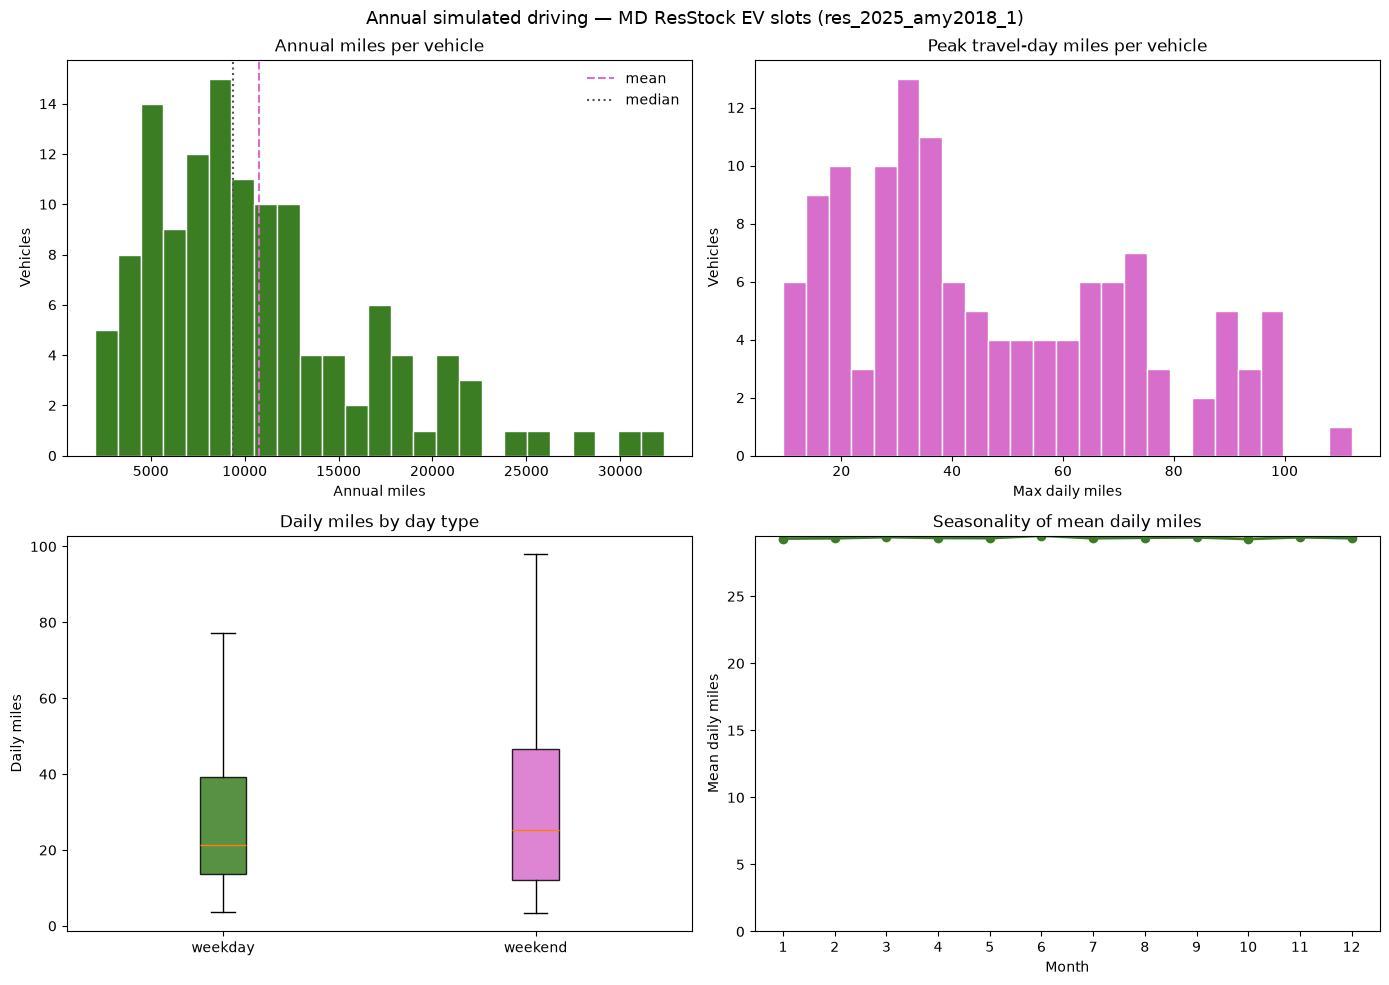

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f"Annual simulated driving — {STATE} ResStock EV slots ({RELEASE_2025})",
    fontsize=13,
)

ax = axes[0, 0]
ax.hist(annual_miles_2025["annual_miles"].to_numpy(), bins=25, color=COLOR_GREEN, edgecolor="white")
ax.axvline(
    annual_miles_2025["annual_miles"].mean(),
    color=COLOR_PINK,
    linestyle="--",
    linewidth=1.5,
    label="mean",
)
ax.axvline(
    annual_miles_2025["annual_miles"].median(),
    color="#555555",
    linestyle=":",
    linewidth=1.5,
    label="median",
)
ax.set_xlabel("Annual miles")
ax.set_ylabel("Vehicles")
ax.set_title("Annual miles per vehicle")
ax.legend(frameon=False)

ax = axes[0, 1]
ax.hist(annual_miles_2025["max_daily_miles"].to_numpy(), bins=25, color=COLOR_PINK, edgecolor="white")
ax.set_xlabel("Max daily miles")
ax.set_ylabel("Vehicles")
ax.set_title("Peak travel-day miles per vehicle")

ax = axes[1, 0]
box_data = [
    daily_miles_2025.filter(pl.col("day_type") == d)["daily_miles"].to_numpy()
    for d in ["weekday", "weekend"]
]
bp = ax.boxplot(box_data, tick_labels=["weekday", "weekend"], showfliers=False, patch_artist=True)
for patch, color in zip(bp["boxes"], [COLOR_GREEN, COLOR_PINK], strict=False):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
ax.set_ylabel("Daily miles")
ax.set_title("Daily miles by day type")

ax = axes[1, 1]
monthly = (
    daily_miles_2025.group_by("month")
    .agg(pl.col("daily_miles").mean().alias("mean_miles"))
    .sort("month")
)
ax.plot(
    monthly["month"].to_numpy(),
    monthly["mean_miles"].to_numpy(),
    color=COLOR_GREEN,
    marker="o",
    linewidth=2,
)
ax.set_xticks(range(1, 13))
ax.set_xlabel("Month")
ax.set_ylabel("Mean daily miles")
ax.set_title("Seasonality of mean daily miles")
ax.set_ylim(bottom=0)

fig.tight_layout()
plt.show()


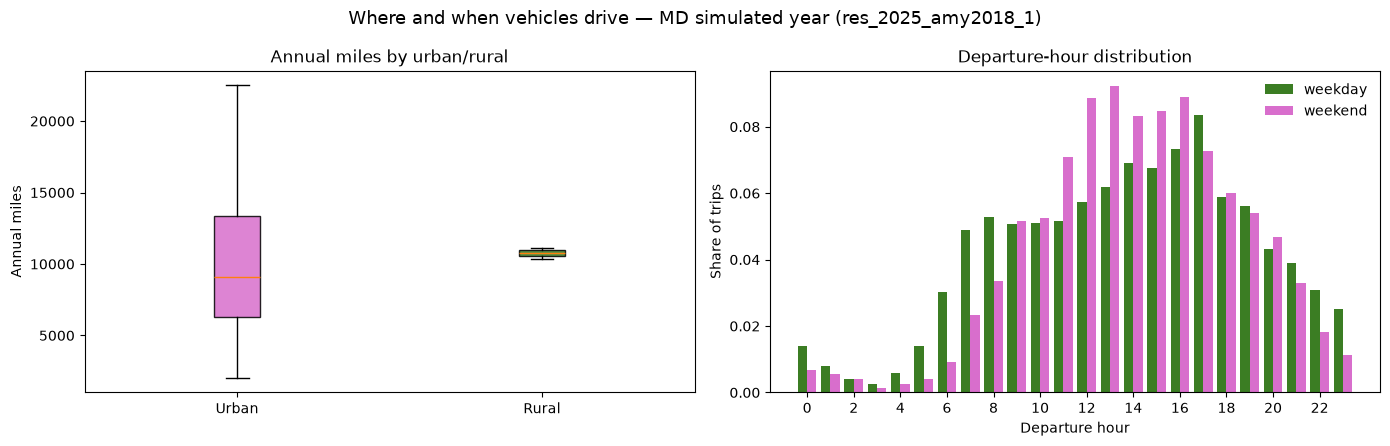

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle(f"Where and when vehicles drive — {STATE} simulated year ({RELEASE_2025})", fontsize=13)

ax = axes[0]
urban_order = ["Urban", "Rural"]
box_data = [
    annual_miles_2025.filter(pl.col("urban_label") == g)["annual_miles"].to_numpy()
    for g in urban_order
]
bp = ax.boxplot(box_data, tick_labels=urban_order, showfliers=False, patch_artist=True)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(COLOR_PINK if i % 2 == 0 else COLOR_GREEN)
    patch.set_alpha(0.85)
ax.set_ylabel("Annual miles")
ax.set_title("Annual miles by urban/rural")

ax = axes[1]
trips_with_day = trip_schedules_2025.with_columns(
    pl.when(pl.col("date").dt.weekday() <= 5)
    .then(pl.lit("weekday"))
    .otherwise(pl.lit("weekend"))
    .alias("day_type")
)
hours = np.arange(24)
width = 0.4
for i, (day, color) in enumerate([("weekday", COLOR_GREEN), ("weekend", COLOR_PINK)]):
    counts = (
        trips_with_day.filter(pl.col("day_type") == day)
        .group_by("departure_hour")
        .agg(pl.len().alias("n"))
        .sort("departure_hour")
    )
    count_map = dict(zip(counts["departure_hour"].to_list(), counts["n"].to_list(), strict=False))
    vals = np.array([count_map.get(h, 0) for h in hours], dtype=float)
    vals = vals / vals.sum() if vals.sum() else vals
    ax.bar(hours + (i - 0.5) * width, vals, width=width, label=day, color=color)
ax.set_xlabel("Departure hour")
ax.set_ylabel("Share of trips")
ax.set_title("Departure-hour distribution")
ax.set_xticks(range(0, 24, 2))
ax.legend(frameon=False)

fig.tight_layout()
plt.show()


Example building 3870 vehicle 1: 4952 annual miles, 940 trips


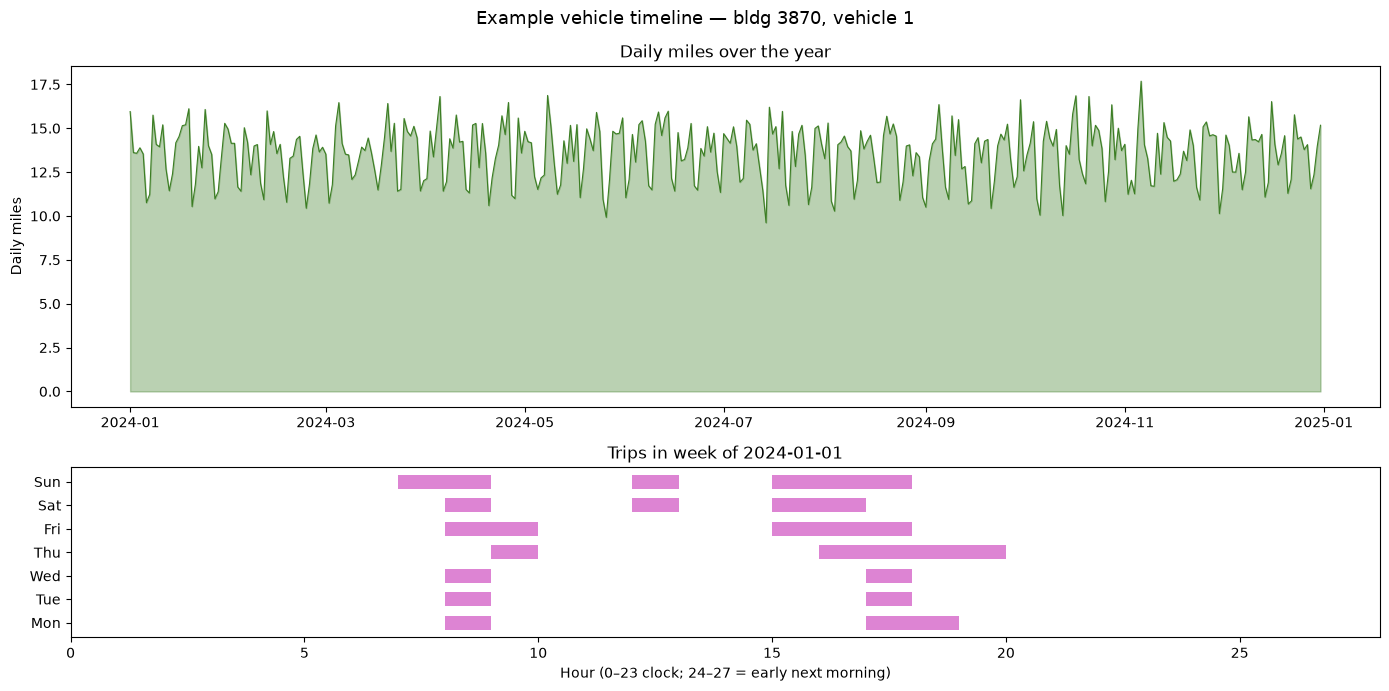

In [ ]:
# Example vehicle: daily miles over the year + a one-week trip strip
from datetime import timedelta

example_key = next(k for k, p in vehicle_profiles.items() if p.weekday.has_trips and p.weekend.has_trips)
example_bldg, example_vid = example_key
example_daily = (
    daily_miles.filter((pl.col("bldg_id") == example_bldg) & (pl.col("vehicle_id") == example_vid))
    .sort("date")
)
example_trips = trip_schedules.filter(
    (pl.col("bldg_id") == example_bldg) & (pl.col("vehicle_id") == example_vid)
).sort("date", "departure_hour")

print(
    f"Example building {example_bldg} vehicle {example_vid}: "
    f"{example_daily['daily_miles'].sum():.0f} annual miles, "
    f"{example_trips.height:,} trips"
)

# First Monday travel day in the year (iso weekday: Mon=1)
week_monday = (
    example_daily.filter(pl.col("iso_weekday") == 1).sort("date")["date"].to_list()[0]
)
week_end = week_monday + timedelta(days=7)
week_trips = example_trips.filter(
    (pl.col("date") >= week_monday) & (pl.col("date") < week_end)
)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={"height_ratios": [2, 1]})
fig.suptitle(f"Example vehicle timeline — bldg {example_bldg}, vehicle {example_vid}", fontsize=13)

ax = axes[0]
ax.fill_between(
    example_daily["date"].to_numpy(),
    example_daily["daily_miles"].to_numpy(),
    color=COLOR_GREEN,
    alpha=0.35,
)
ax.plot(
    example_daily["date"].to_numpy(),
    example_daily["daily_miles"].to_numpy(),
    color=COLOR_GREEN,
    linewidth=0.8,
)
ax.set_ylabel("Daily miles")
ax.set_title("Daily miles over the year")

ax = axes[1]
for row in week_trips.iter_rows(named=True):
    day_offset = (row["date"] - week_monday).days
    dep = float(row["departure_hour"])
    arr = float(row["arrival_hour"])
    if row["arrival_date"] > row["departure_date"]:
        arr += 24.0
    ax.barh(day_offset, max(arr - dep, 0.5), left=dep, height=0.6, color=COLOR_PINK, alpha=0.85)
ax.set_yticks(range(7))
ax.set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax.set_xlim(0, 28)
ax.set_xlabel("Hour (0–23 clock; 24–27 = early next morning)")
ax.set_title(f"Trips in week of {week_monday.date()}")

fig.tight_layout()
plt.show()


## 6. EV battery / vehicle-type assignment

ResStock defines **8** national BEV options (4 body classes × 200/300-mile range) with stock
shares from Experian/TEMPO. After trip schedules are generated, each EV draws from that prior
**conditioned on feasibility**: usable pack must cover
`max_daily_miles × kWh/mi × (1 + buffer)`.

Below: national prior shares vs what this MD sample actually draws.


In [ ]:
# National prior + Autonomie physics tables
ev_battery_df = load_ev_battery_lookup(config.ev_battery_path)
ev_autonomie_df = load_ev_autonomie_params(config.ev_autonomie_path)

prior_options = (
    ev_battery_df.join(ev_autonomie_df, on="ev_option_name", how="left")
    .with_columns(
        (
            pl.col("body_class") + " " + pl.col("range_miles").cast(pl.Utf8) + "-mi"
        ).alias("option_short"),
    )
    .sort("probability", descending=True)
)

print(f"ResStock BEV options: {prior_options.height}")
print(f"Prior probabilities sum: {prior_options['probability'].sum():.6f}")
print(f"Capacity buffer fraction: {config.capacity_buffer_fraction}")
display(
    prior_options.select(
        "option_short",
        "ev_option_name",
        "probability",
        "body_class",
        "range_miles",
        "battery_capacity_kwh",
        "kwh_per_mile",
    )
)


ResStock BEV options: 8
Prior probabilities sum: 1.000000
Capacity buffer fraction: 0.2


option_short,ev_option_name,probability,body_class,range_miles,battery_capacity_kwh,kwh_per_mile
str,str,f64,str,i64,f64,f64
"""Compact 300-mi""","""Compact, Battery Electric Vehi…",0.339087,"""Compact""",300,63.433,0.22002
"""SUV 300-mi""","""SUV, Battery Electric Vehicle,…",0.306398,"""SUV""",300,83.68,0.278934
"""SUV 200-mi""","""SUV, Battery Electric Vehicle,…",0.122608,"""SUV""",200,53.503,0.267513
"""Compact 200-mi""","""Compact, Battery Electric Vehi…",0.11868,"""Compact""",200,40.168,0.209901
"""Midsize 300-mi""","""Midsize, Battery Electric Vehi…",0.0760135,"""Midsize""",300,65.441,0.229449
"""Midsize 200-mi""","""Midsize, Battery Electric Vehi…",0.0295077,"""Midsize""",200,41.978,0.219174
"""Pickup 300-mi""","""Pickup, Battery Electric Vehic…",0.007651,"""Pickup""",300,105.946,0.373794
"""Pickup 200-mi""","""Pickup, Battery Electric Vehic…",0.000055,"""Pickup""",200,67.738,0.357648


In [ ]:
# Stock-conditional assignment: feasible packs only, renormalized prior shares
vehicle_duty = TripScheduleGenerator.max_daily_miles_from_trip_schedules(trip_schedules)

battery_assigner = EVBatteryAssigner(
    option_probabilities=ev_battery_df,
    autonomie_params=ev_autonomie_df,
    random_state=SEED,
)
ev_attributes = battery_assigner.assign(
    vehicle_duty,
    buffer_fraction=config.capacity_buffer_fraction,
).join(
    prior_options.select("ev_option_name", "option_short"),
    on="ev_option_name",
    how="left",
)

print(f"Assigned battery attributes for {ev_attributes.height:,} EV slot(s)")
display(
    ev_attributes.select(
        "bldg_id",
        "vehicle_id",
        "max_daily_miles",
        "option_short",
        "body_class",
        "range_miles",
        "battery_capacity_kwh",
        "kwh_per_mile",
    ).head(10)
)


Assigned battery attributes for 178 EV slot(s)


bldg_id,vehicle_id,max_daily_miles,option_short,body_class,range_miles,battery_capacity_kwh,kwh_per_mile
i64,i64,f64,str,str,i64,f64,f64
245432,1,37.49236,"""SUV 300-mi""","""SUV""",300,83.68,0.278934
390583,1,98.714562,"""Compact 300-mi""","""Compact""",300,63.433,0.22002
115297,1,22.176574,"""SUV 300-mi""","""SUV""",300,83.68,0.278934
5498,1,30.377855,"""SUV 300-mi""","""SUV""",300,83.68,0.278934
372394,1,40.819596,"""Compact 200-mi""","""Compact""",200,40.168,0.209901
238899,1,29.083952,"""SUV 300-mi""","""SUV""",300,83.68,0.278934
327729,1,43.220496,"""SUV 300-mi""","""SUV""",300,83.68,0.278934
453716,1,93.746344,"""SUV 300-mi""","""SUV""",300,83.68,0.278934
46122,1,93.312169,"""Compact 300-mi""","""Compact""",300,63.433,0.22002


In [ ]:
# Prior vs sampled option shares
n_assigned = ev_attributes.height
sampled_counts = (
    ev_attributes.group_by("ev_option_name", "option_short", "body_class", "range_miles")
    .agg(pl.len().alias("n_sampled"))
    .with_columns((pl.col("n_sampled") / n_assigned).alias("sampled_share"))
)

option_comparison = (
    prior_options.select(
        "ev_option_name",
        "option_short",
        "body_class",
        "range_miles",
        "probability",
        "battery_capacity_kwh",
        "kwh_per_mile",
    )
    .join(sampled_counts, on=["ev_option_name", "option_short", "body_class", "range_miles"], how="left")
    .with_columns(
        pl.col("n_sampled").fill_null(0),
        pl.col("sampled_share").fill_null(0.0),
        (pl.col("probability") * n_assigned).alias("expected_under_prior"),
    )
    .with_columns(
        (pl.col("n_sampled") - pl.col("expected_under_prior")).alias("count_delta"),
        (pl.col("sampled_share") - pl.col("probability")).alias("share_delta"),
    )
    .sort("probability", descending=True)
)

print(f"Assigned EV slots: {n_assigned:,}")
print("Prior (national stock) vs sampled (duty-conditional) shares")
display(
    option_comparison.select(
        "option_short",
        pl.col("probability").round(4).alias("prior_share"),
        pl.col("sampled_share").round(4),
        pl.col("share_delta").round(4),
        "n_sampled",
        pl.col("expected_under_prior").round(1),
        pl.col("count_delta").round(1),
        "battery_capacity_kwh",
        "kwh_per_mile",
    )
)

print("\nBy body class")
display(
    option_comparison.group_by("body_class")
    .agg(
        pl.col("probability").sum().round(4).alias("prior_share"),
        pl.col("sampled_share").sum().round(4).alias("sampled_share"),
        pl.col("n_sampled").sum().alias("n_sampled"),
    )
    .with_columns((pl.col("sampled_share") - pl.col("prior_share")).round(4).alias("share_delta"))
    .sort("prior_share", descending=True)
)

print("\nBy range")
display(
    option_comparison.group_by("range_miles")
    .agg(
        pl.col("probability").sum().round(4).alias("prior_share"),
        pl.col("sampled_share").sum().round(4).alias("sampled_share"),
        pl.col("n_sampled").sum().alias("n_sampled"),
    )
    .with_columns((pl.col("sampled_share") - pl.col("prior_share")).round(4).alias("share_delta"))
    .sort("range_miles")
)

print("\nAssigned pack summary")
display(
    ev_attributes.select("battery_capacity_kwh", "kwh_per_mile", "range_miles", "max_daily_miles").describe()
)


Assigned EV slots: 178
Prior (national stock) vs sampled (duty-conditional) shares


option_short,prior_share,sampled_share,share_delta,n_sampled,expected_under_prior,count_delta,battery_capacity_kwh,kwh_per_mile
str,f64,f64,f64,u32,f64,f64,f64,f64
"""Compact 300-mi""",0.3391,0.3427,0.0036,61,60.4,0.6,63.433,0.22002
"""SUV 300-mi""",0.3064,0.2921,-0.0143,52,54.5,-2.5,83.68,0.278934
"""SUV 200-mi""",0.1226,0.118,-0.0046,21,21.8,-0.8,53.503,0.267513
"""Compact 200-mi""",0.1187,0.1236,0.0049,22,21.1,0.9,40.168,0.209901
"""Midsize 300-mi""",0.076,0.0618,-0.0142,11,13.5,-2.5,65.441,0.229449
"""Midsize 200-mi""",0.0295,0.0506,0.0211,9,5.3,3.7,41.978,0.219174
"""Pickup 300-mi""",0.0077,0.0112,0.0036,2,1.4,0.6,105.946,0.373794
"""Pickup 200-mi""",0.0001,0.0,-0.0001,0,0.0,-0.0,67.738,0.357648



By body class


body_class,prior_share,sampled_share,n_sampled,share_delta
str,f64,f64,u32,f64
"""Compact""",0.4578,0.4663,83,0.0085
"""SUV""",0.429,0.4101,73,-0.0189
"""Midsize""",0.1055,0.1124,20,0.0069
"""Pickup""",0.0077,0.0112,2,0.0035



By range


range_miles,prior_share,sampled_share,n_sampled,share_delta
i64,f64,f64,u32,f64
200,0.2709,0.2921,52,0.0212
300,0.7291,0.7079,126,-0.0212



Assigned pack summary


statistic,battery_capacity_kwh,kwh_per_mile,range_miles,max_daily_miles
str,f64,f64,f64,f64
"""count""",178.0,178.0,178.0,178.0
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",64.817848,0.243851,270.786517,44.395977
"""std""",15.542162,0.031649,45.602674,26.545281
"""min""",40.168,0.209901,200.0,7.002054
"""25%""",53.503,0.22002,200.0,23.155728
"""50%""",63.433,0.22002,300.0,36.184123
"""75%""",83.68,0.278934,300.0,61.714935
"""max""",105.946,0.373794,300.0,100.005863


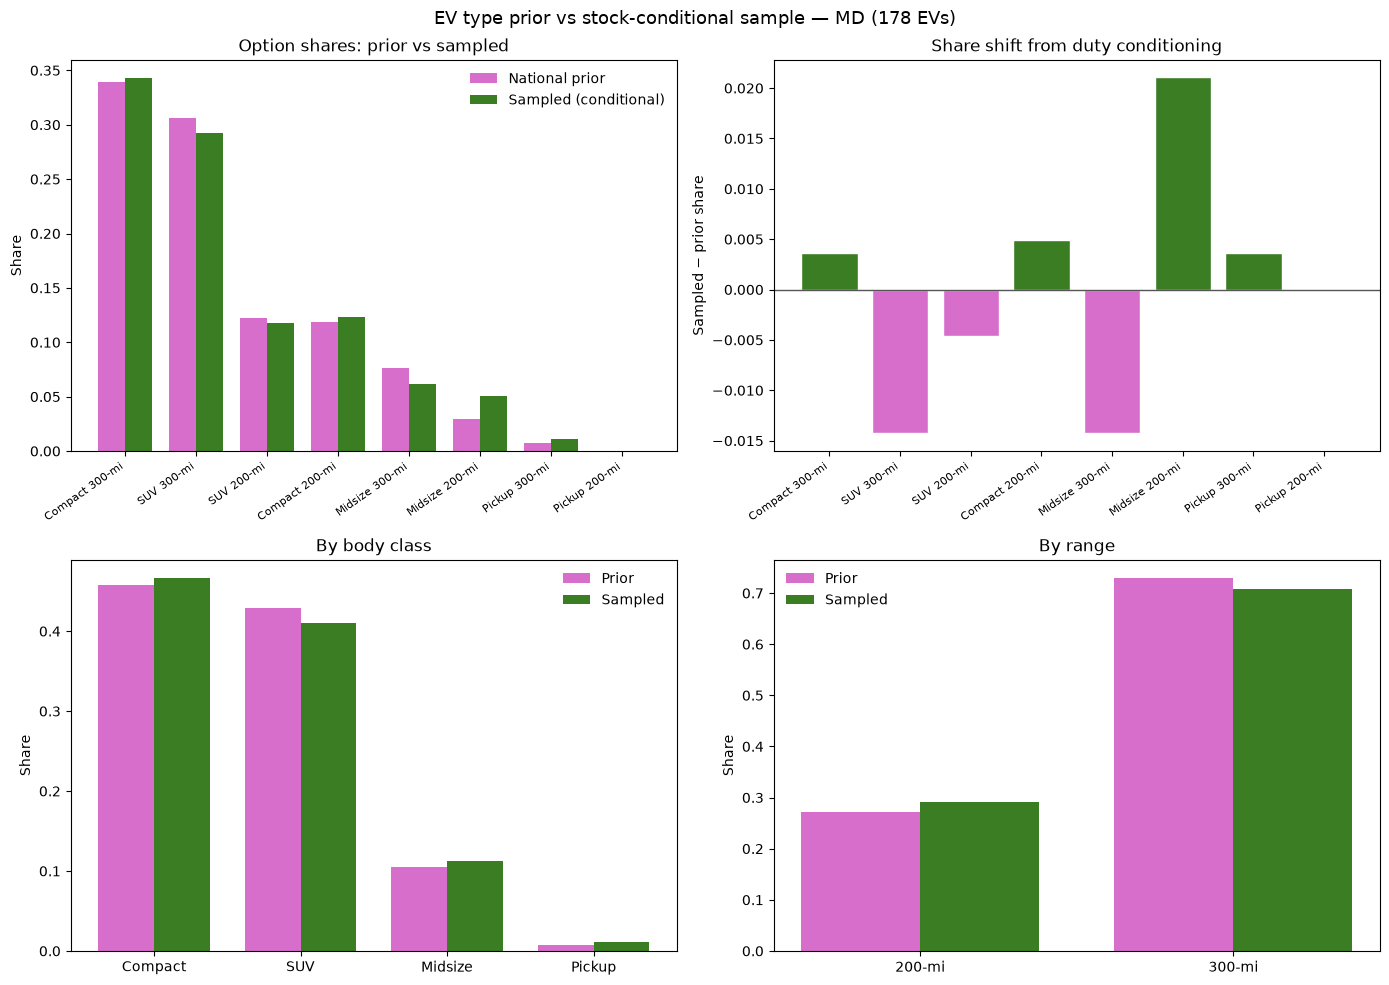

In [ ]:
# Prior vs sampled: grouped bars by option, plus body-class and range rollups
option_order = option_comparison.sort("probability", descending=True)["option_short"].to_list()
x = np.arange(len(option_order))
width = 0.38
prior_vals = [
    float(option_comparison.filter(pl.col("option_short") == o)["probability"][0])
    for o in option_order
]
sampled_vals = [
    float(option_comparison.filter(pl.col("option_short") == o)["sampled_share"][0])
    for o in option_order
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f"EV type prior vs stock-conditional sample — {STATE} ({n_assigned} EVs)",
    fontsize=13,
)

ax = axes[0, 0]
ax.bar(x - width / 2, prior_vals, width, label="National prior", color=COLOR_PINK)
ax.bar(x + width / 2, sampled_vals, width, label="Sampled (conditional)", color=COLOR_GREEN)
ax.set_xticks(x)
ax.set_xticklabels(option_order, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Share")
ax.set_title("Option shares: prior vs sampled")
ax.legend(frameon=False)

ax = axes[0, 1]
deltas = np.array(sampled_vals) - np.array(prior_vals)
bar_colors = [COLOR_GREEN if d >= 0 else COLOR_PINK for d in deltas]
ax.bar(x, deltas, color=bar_colors, edgecolor="white")
ax.axhline(0, color="#555555", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(option_order, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Sampled − prior share")
ax.set_title("Share shift from duty conditioning")

# Body class rollup
body = (
    option_comparison.group_by("body_class")
    .agg(
        pl.col("probability").sum().alias("prior_share"),
        pl.col("sampled_share").sum().alias("sampled_share"),
    )
    .sort("prior_share", descending=True)
)
bx = np.arange(body.height)
ax = axes[1, 0]
ax.bar(bx - width / 2, body["prior_share"].to_numpy(), width, label="Prior", color=COLOR_PINK)
ax.bar(bx + width / 2, body["sampled_share"].to_numpy(), width, label="Sampled", color=COLOR_GREEN)
ax.set_xticks(bx)
ax.set_xticklabels(body["body_class"].to_list())
ax.set_ylabel("Share")
ax.set_title("By body class")
ax.legend(frameon=False)

# Range rollup
rng = (
    option_comparison.group_by("range_miles")
    .agg(
        pl.col("probability").sum().alias("prior_share"),
        pl.col("sampled_share").sum().alias("sampled_share"),
    )
    .sort("range_miles")
)
rx = np.arange(rng.height)
ax = axes[1, 1]
ax.bar(rx - width / 2, rng["prior_share"].to_numpy(), width, label="Prior", color=COLOR_PINK)
ax.bar(rx + width / 2, rng["sampled_share"].to_numpy(), width, label="Sampled", color=COLOR_GREEN)
ax.set_xticks(rx)
ax.set_xticklabels([f"{r}-mi" for r in rng["range_miles"].to_list()])
ax.set_ylabel("Share")
ax.set_title("By range")
ax.legend(frameon=False)

fig.tight_layout()
plt.show()


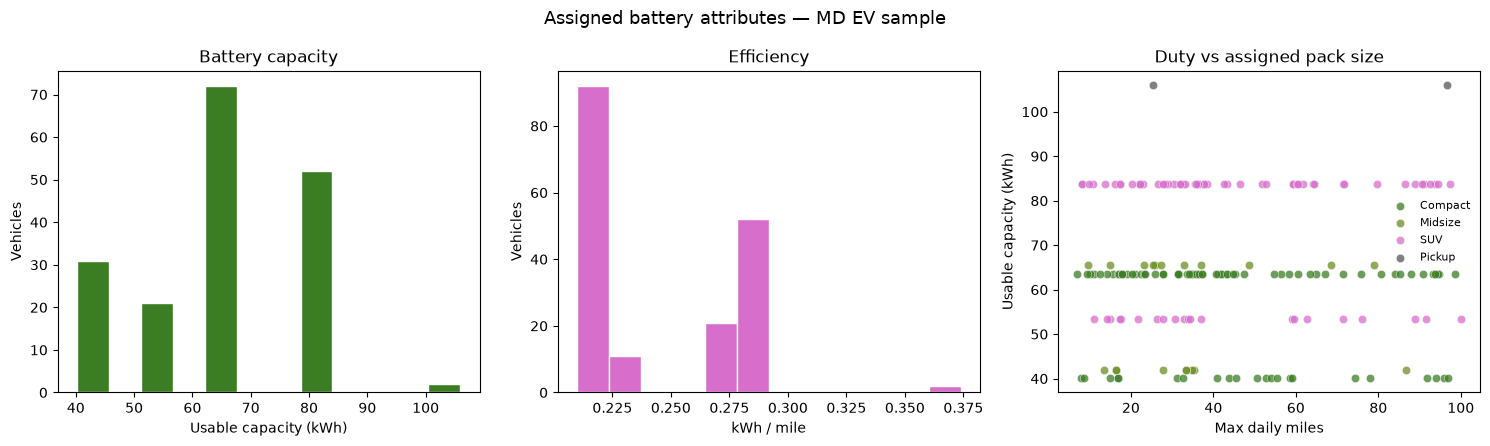

Miles headroom after buffer (usable range − max daily miles)


statistic,miles_headroom,max_daily_miles,battery_capacity_kwh,range_miles
str,f64,f64,f64,f64
"""count""",178.0,178.0,178.0,178.0
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",219.787294,44.395977,64.817848,270.786517
"""std""",52.5722,26.545281,15.542162,45.602674
"""min""",94.435574,7.002054,40.168,200.0
"""25%""",178.197251,23.155728,53.503,200.0
"""50%""",239.379402,36.184123,63.433,300.0
"""75%""",263.606585,61.714935,83.68,300.0
"""max""",291.944017,100.005863,105.946,300.0


In [ ]:
# Assigned pack characteristics
BODY_COLORS = {
    "Compact": COLOR_GREEN,
    "Midsize": "#6B8E23",
    "SUV": COLOR_PINK,
    "Pickup": "#555555",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle(f"Assigned battery attributes — {STATE} EV sample", fontsize=13)

ax = axes[0]
ax.hist(ev_attributes["battery_capacity_kwh"].to_numpy(), bins=12, color=COLOR_GREEN, edgecolor="white")
ax.set_xlabel("Usable capacity (kWh)")
ax.set_ylabel("Vehicles")
ax.set_title("Battery capacity")

ax = axes[1]
ax.hist(ev_attributes["kwh_per_mile"].to_numpy(), bins=12, color=COLOR_PINK, edgecolor="white")
ax.set_xlabel("kWh / mile")
ax.set_ylabel("Vehicles")
ax.set_title("Efficiency")

ax = axes[2]
for body, color in BODY_COLORS.items():
    sub = ev_attributes.filter(pl.col("body_class") == body)
    if sub.is_empty():
        continue
    ax.scatter(
        sub["max_daily_miles"].to_numpy(),
        sub["battery_capacity_kwh"].to_numpy(),
        c=color,
        label=body,
        alpha=0.75,
        edgecolors="white",
        linewidths=0.4,
    )
ax.set_xlabel("Max daily miles")
ax.set_ylabel("Usable capacity (kWh)")
ax.set_title("Duty vs assigned pack size")
ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.show()

headroom = ev_attributes.with_columns(
    (
        pl.col("battery_capacity_kwh")
        / pl.col("kwh_per_mile")
        - pl.col("max_daily_miles")
    ).alias("miles_headroom")
)
print("Miles headroom after buffer (usable range − max daily miles)")
display(
    headroom.select("miles_headroom", "max_daily_miles", "battery_capacity_kwh", "range_miles").describe()
)


## 7. Charging policies — one MD building

Same trips and battery for building **3870**, mid-year week. Four strategies:

| Strategy | Behavior |
|---|---|
| `immediate` | Charge at Level 2 whenever home and not full |
| `off_peak` | Charge only off-peak until daily SOC target |
| `off_peak_immediate` | Charge at Level 2 whenever home and off-peak (config default) |
| `cost_minimizing` | Perfect-foresight LP on a simple TOU price (peak \$0.20, off-peak \$0.10) |

Peak hours follow the config: 17–21. Discharge is identical across strategies (same trips).


In [ ]:
from datetime import datetime, timedelta

DEMO_BLDG = 3870
# Mid-year Mon–Sun travel week (July 1 2024 is a Monday)
WINDOW_START = datetime(2024, 7, 1, 4, 0, 0)
WINDOW_END = datetime(2024, 7, 8, 3, 0, 0)  # inclusive last hour slot

demo_trips = trip_schedules.filter(pl.col("bldg_id") == DEMO_BLDG)
demo_attrs = ev_attributes.filter(pl.col("bldg_id") == DEMO_BLDG)
assert demo_attrs.height >= 1, f"No battery attrs for bldg_id={DEMO_BLDG}"
assert demo_trips.height >= 1, f"No trips for bldg_id={DEMO_BLDG}"

print(f"Building {DEMO_BLDG}: {demo_trips.height:,} trip rows, vehicle slot(s) {demo_attrs['vehicle_id'].to_list()}")
display(demo_attrs.select(
    "bldg_id", "vehicle_id", "ev_option_name", "battery_capacity_kwh", "kwh_per_mile", "max_daily_miles"
))

charging_sim = ChargingSimulator(start_date=config.start_date, end_date=config.end_date)
hours_base = build_hours_base(config.start_date, config.end_date)
peak_hours = tuple(config.peak_clock_hours) if config.peak_clock_hours else (17, 18, 19, 20, 21)

# Simple TOU for cost-minimizing (matches peak_clock_hours)
hourly_tou_prices = (
    hours_base.with_columns(
        pl.when(pl.col("timestamp").dt.hour().is_in(list(peak_hours)))
        .then(0.20)
        .otherwise(0.10)
        .alias("price")
    )["price"]
    .to_numpy()
)

presence_by_vehicle = charging_sim.generate_presence(
    demo_trips, hours_base=hours_base
)

soc_common = dict(
    trip_schedules=demo_trips,
    ev_attributes=demo_attrs,
    hours_base=hours_base,
    presence_by_vehicle=presence_by_vehicle,
    charger_power_kw=config.charger_power_kw,
    initial_soc_kwh=config.initial_soc_kwh,
)

strategy_kwargs = {
    "immediate": {},
    "off_peak": {
        "peak_clock_hours": peak_hours,
        "soc_min_fraction": config.soc_min_fraction if config.soc_min_fraction is not None else DEFAULT_SOC_MIN_FRACTION,
        "soc_safety_buffer_fraction": (
            config.soc_safety_buffer_fraction
            if config.soc_safety_buffer_fraction is not None
            else DEFAULT_SOC_SAFETY_BUFFER_FRACTION
        ),
    },
    "off_peak_immediate": {
        "peak_clock_hours": peak_hours,
        "allow_emergency_peak_charging": bool(config.allow_emergency_peak_charging),
    },
    "cost_minimizing": {
        "hourly_price_usd_per_kwh": hourly_tou_prices,
        "shed_load_penalty_usd_per_kwh": (
            config.shed_load_penalty_usd_per_kwh
            if config.shed_load_penalty_usd_per_kwh is not None
            else 1_000_000.0
        ),
    },
}

soc_by_strategy: dict[str, pl.DataFrame] = {}
for strategy, extra in strategy_kwargs.items():
    soc = charging_sim.generate_soc(charging_strategy=strategy, **soc_common, **extra)
    soc_by_strategy[strategy] = soc
    print(
        f"{strategy:20s}  annual charge={soc['charge_kwh'].sum():7.1f} kWh  "
        f"discharge={soc['discharge_kwh'].sum():7.1f} kWh"
    )


Building 3870: 940 trip rows, vehicle slot(s) [1]


bldg_id,vehicle_id,ev_option_name,battery_capacity_kwh,kwh_per_mile,max_daily_miles
i64,i64,str,f64,f64,f64
3870,1,"""SUV, Battery Electric Vehicle,…",53.503,0.267513,17.683439


immediate             annual charge= 1324.8 kWh  discharge= 1324.8 kWh
off_peak              annual charge= 1282.0 kWh  discharge= 1324.8 kWh
off_peak_immediate    annual charge= 1324.8 kWh  discharge= 1324.8 kWh
cost_minimizing       annual charge= 1271.3 kWh  discharge= 1324.8 kWh


In [ ]:
def _window_slice(soc: pl.DataFrame) -> pl.DataFrame:
    return (
        soc.filter(
            (pl.col("timestamp") >= WINDOW_START) & (pl.col("timestamp") <= WINDOW_END)
        )
        .sort("timestamp")
        .with_columns(
            pl.col("timestamp").dt.hour().alias("clock_hour"),
            pl.col("timestamp").dt.hour().is_in(list(peak_hours)).alias("is_peak"),
        )
    )


window_by_strategy = {s: _window_slice(soc) for s, soc in soc_by_strategy.items()}

# Week summary: charge / discharge and how much charging landed on peak hours
summary_rows = []
for strategy, win in window_by_strategy.items():
    charge = float(win["charge_kwh"].sum())
    discharge = float(win["discharge_kwh"].sum())
    peak_charge = float(win.filter(pl.col("is_peak"))["charge_kwh"].sum())
    summary_rows.append({
        "strategy": strategy,
        "window_charge_kwh": round(charge, 2),
        "window_discharge_kwh": round(discharge, 2),
        "peak_charge_kwh": round(peak_charge, 2),
        "peak_charge_share": round(peak_charge / charge, 3) if charge > 0 else 0.0,
        "underflow_hours": int(win.filter(pl.col("soc_underflow")).height),
    })

print(f"Building {DEMO_BLDG} — {WINDOW_START.date()} → {WINDOW_END.date()} (peak hours {list(peak_hours)})")
display(pl.DataFrame(summary_rows))


Building 3870 — 2024-07-01 → 2024-07-08 (peak hours [17, 18, 19, 20, 21])


strategy,window_charge_kwh,window_discharge_kwh,peak_charge_kwh,peak_charge_share,underflow_hours
str,f64,f64,f64,f64,i64
"""immediate""",25.78,25.78,14.85,0.576,0
"""off_peak""",25.99,25.78,0.0,0.0,0
"""off_peak_immediate""",25.78,25.78,0.0,0.0,0
"""cost_minimizing""",25.61,25.78,0.0,0.0,0


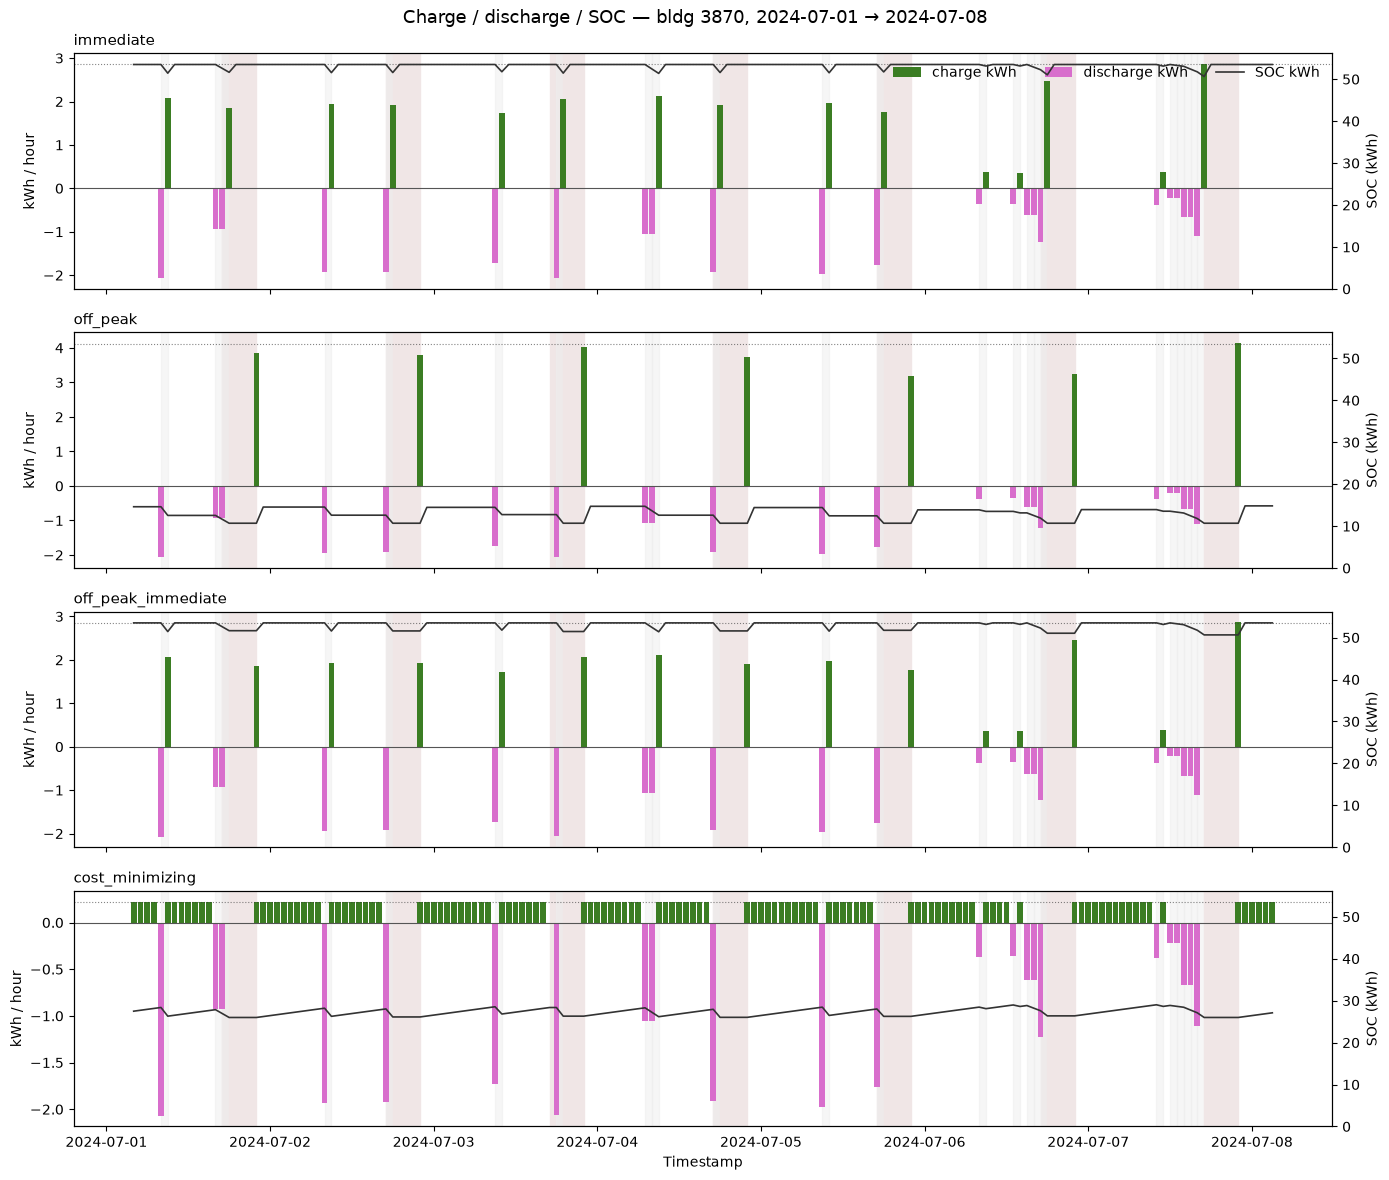

In [ ]:
strategies = ["immediate", "off_peak", "off_peak_immediate", "cost_minimizing"]
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle(
    f"Charge / discharge / SOC — bldg {DEMO_BLDG}, {WINDOW_START.date()} → {(WINDOW_END - timedelta(hours=3)).date()}",
    fontsize=13,
)

battery_kwh = float(demo_attrs["battery_capacity_kwh"][0])

for ax, strategy in zip(axes, strategies):
    win = window_by_strategy[strategy]
    ts = win["timestamp"].to_numpy()
    charge = win["charge_kwh"].to_numpy()
    discharge = win["discharge_kwh"].to_numpy()
    soc = win["soc_kwh"].to_numpy()
    at_home = win["at_home"].to_numpy()
    is_peak = win["is_peak"].to_numpy()

    # Shade peak hours and away hours
    for i in range(len(ts)):
        if is_peak[i]:
            ax.axvspan(ts[i], ts[i] + np.timedelta64(1, "h"), color="#f0e6e6", zorder=0)
        if not at_home[i]:
            ax.axvspan(ts[i], ts[i] + np.timedelta64(1, "h"), color="#eeeeee", alpha=0.5, zorder=0)

    ax.bar(ts, charge, width=np.timedelta64(50, "m"), color=COLOR_GREEN, label="charge kWh", zorder=2)
    ax.bar(ts, -discharge, width=np.timedelta64(50, "m"), color=COLOR_PINK, label="discharge kWh", zorder=2)
    ax.set_ylabel("kWh / hour")
    ax.axhline(0, color="#555555", linewidth=0.8)

    ax2 = ax.twinx()
    ax2.plot(ts, soc, color="#333333", linewidth=1.2, label="SOC kWh", zorder=3)
    ax2.set_ylabel("SOC (kWh)")
    ax2.set_ylim(0, battery_kwh * 1.05)
    ax2.axhline(battery_kwh, color="#333333", linestyle=":", linewidth=0.8, alpha=0.6)

    ax.set_title(strategy, loc="left", fontsize=11)
    if strategy == strategies[0]:
        # Combined legend once
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, loc="upper right", frameon=False, ncols=3)

axes[-1].set_xlabel("Timestamp")
fig.tight_layout()
plt.show()


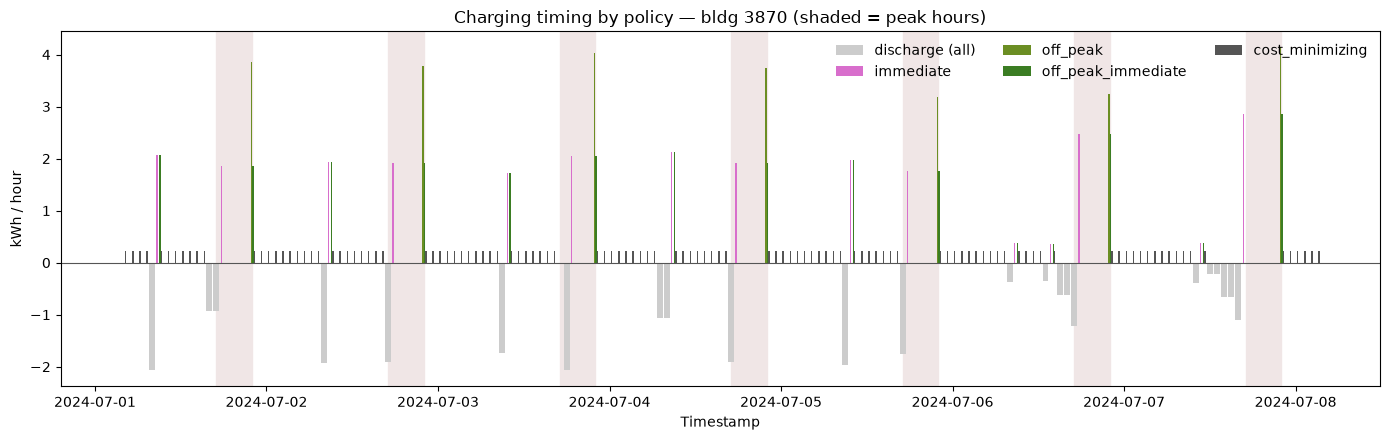

In [ ]:
# Side-by-side charge profiles only (same discharge underneath)
fig, ax = plt.subplots(figsize=(14, 4.5))
width = np.timedelta64(12, "m")
offsets = {
    "immediate": -1.5 * width,
    "off_peak": -0.5 * width,
    "off_peak_immediate": 0.5 * width,
    "cost_minimizing": 1.5 * width,
}
colors = {
    "immediate": COLOR_PINK,
    "off_peak": "#6B8E23",
    "off_peak_immediate": COLOR_GREEN,
    "cost_minimizing": "#555555",
}

# Use immediate window timestamps as the x spine; discharge once as reference
ref = window_by_strategy["immediate"]
ts = ref["timestamp"].to_numpy()
ax.bar(ts, -ref["discharge_kwh"].to_numpy(), width=np.timedelta64(50, "m"),
       color="#cccccc", label="discharge (all)", zorder=1)

for strategy in strategies:
    win = window_by_strategy[strategy]
    ax.bar(
        win["timestamp"].to_numpy() + offsets[strategy],
        win["charge_kwh"].to_numpy(),
        width=width,
        color=colors[strategy],
        label=strategy,
        zorder=2,
    )

for i, t in enumerate(ts):
    if bool(ref["is_peak"][i]):
        ax.axvspan(t, t + np.timedelta64(1, "h"), color="#f0e6e6", zorder=0)

ax.axhline(0, color="#555555", linewidth=0.8)
ax.set_ylabel("kWh / hour")
ax.set_xlabel("Timestamp")
ax.set_title(f"Charging timing by policy — bldg {DEMO_BLDG} (shaded = peak hours)")
ax.legend(frameon=False, ncols=3)
fig.tight_layout()
plt.show()


## 8. Fleet aggregate hourly charging load

Same four strategies on **all** MD EV slots, then sum `charge_kwh` across vehicles.

- **Load curves:** first week of July 2024 (Mon 7/1 04:00 → Mon 7/8 03:00)
- **Peak demand stats:** max hourly fleet charge over the **full simulation year**

SOC is simulated for the full year so both the July week and annual peaks use a consistent
battery state (no weather / temperature adjustment here — Autonomie `kWh/mi` only).


In [ ]:
# Fleet SOC under each strategy (reuses trip_schedules + ev_attributes from §5–§6)
FLEET_WINDOW_START = datetime(2024, 7, 1, 4, 0, 0)
FLEET_WINDOW_END = datetime(2024, 7, 8, 3, 0, 0)

fleet_charging_sim = ChargingSimulator(start_date=config.start_date, end_date=config.end_date)
fleet_hours_base = build_hours_base(config.start_date, config.end_date)
fleet_peak_hours = tuple(config.peak_clock_hours) if config.peak_clock_hours else (17, 18, 19, 20, 21)

fleet_tou_prices = (
    fleet_hours_base.with_columns(
        pl.when(pl.col("timestamp").dt.hour().is_in(list(fleet_peak_hours)))
        .then(0.20)
        .otherwise(0.10)
        .alias("price")
    )["price"]
    .to_numpy()
)

print(
    f"Building presence for {ev_attributes.height:,} EV slot(s) "
    f"({trip_schedules.height:,} trip rows)..."
)
fleet_presence = fleet_charging_sim.generate_presence(
    trip_schedules, hours_base=fleet_hours_base
)

fleet_soc_common = dict(
    trip_schedules=trip_schedules,
    ev_attributes=ev_attributes,
    hours_base=fleet_hours_base,
    presence_by_vehicle=fleet_presence,
    charger_power_kw=config.charger_power_kw,
    initial_soc_kwh=config.initial_soc_kwh,
)

fleet_strategy_kwargs = {
    "immediate": {},
    "off_peak": {
        "peak_clock_hours": fleet_peak_hours,
        "soc_min_fraction": (
            config.soc_min_fraction if config.soc_min_fraction is not None else DEFAULT_SOC_MIN_FRACTION
        ),
        "soc_safety_buffer_fraction": (
            config.soc_safety_buffer_fraction
            if config.soc_safety_buffer_fraction is not None
            else DEFAULT_SOC_SAFETY_BUFFER_FRACTION
        ),
    },
    "off_peak_immediate": {
        "peak_clock_hours": fleet_peak_hours,
        "allow_emergency_peak_charging": bool(config.allow_emergency_peak_charging),
    },
    "cost_minimizing": {
        "hourly_price_usd_per_kwh": fleet_tou_prices,
        "shed_load_penalty_usd_per_kwh": (
            config.shed_load_penalty_usd_per_kwh
            if config.shed_load_penalty_usd_per_kwh is not None
            else 1_000_000.0
        ),
    },
}

fleet_soc_by_strategy: dict[str, pl.DataFrame] = {}
for strategy, extra in fleet_strategy_kwargs.items():
    print(f"Generating SOC — {strategy}...")
    fleet_soc_by_strategy[strategy] = fleet_charging_sim.generate_soc(
        charging_strategy=strategy, **fleet_soc_common, **extra
    )
    soc = fleet_soc_by_strategy[strategy]
    print(
        f"  rows={soc.height:,}  annual fleet charge={soc['charge_kwh'].sum():,.0f} kWh  "
        f"discharge={soc['discharge_kwh'].sum():,.0f} kWh"
    )


Building presence for 178 EV slot(s) (257,082 trip rows)...
Generating SOC — immediate...


  rows=1,563,552  annual fleet charge=429,843 kWh  discharge=429,872 kWh
Generating SOC — off_peak...
  rows=1,563,552  annual fleet charge=412,601 kWh  discharge=429,872 kWh
Generating SOC — off_peak_immediate...
  rows=1,563,552  annual fleet charge=429,840 kWh  discharge=429,872 kWh
Generating SOC — cost_minimizing...
  rows=1,563,552  annual fleet charge=418,334 kWh  discharge=429,872 kWh


In [ ]:
# Aggregate hourly fleet load: July window (time-series plots) + full year (peak stats)
def fleet_hourly_load(soc: pl.DataFrame, *, start=None, end=None) -> pl.DataFrame:
    frame = soc
    if start is not None:
        frame = frame.filter(pl.col("timestamp") >= start)
    if end is not None:
        frame = frame.filter(pl.col("timestamp") <= end)
    return (
        frame.group_by("timestamp")
        .agg(
            pl.col("charge_kwh").sum().alias("fleet_charge_kwh"),
            pl.col("discharge_kwh").sum().alias("fleet_discharge_kwh"),
            pl.col("bldg_id").n_unique().alias("n_buildings"),
        )
        .sort("timestamp")
        .with_columns(
            pl.col("timestamp").dt.hour().alias("clock_hour"),
            pl.col("timestamp").dt.hour().is_in(list(fleet_peak_hours)).alias("is_peak"),
        )
    )


fleet_load_by_strategy = {
    strategy: fleet_hourly_load(soc, start=FLEET_WINDOW_START, end=FLEET_WINDOW_END)
    for strategy, soc in fleet_soc_by_strategy.items()
}
fleet_annual_load_by_strategy = {
    strategy: fleet_hourly_load(soc) for strategy, soc in fleet_soc_by_strategy.items()
}

# July-week energy totals + annual peak demand stats
fleet_summary_rows = []
for strategy in fleet_soc_by_strategy:
    week = fleet_load_by_strategy[strategy]
    annual = fleet_annual_load_by_strategy[strategy]
    week_charge = week["fleet_charge_kwh"]
    annual_charge = annual["fleet_charge_kwh"]
    annual_peak = annual.filter(pl.col("is_peak"))["fleet_charge_kwh"]
    annual_offpeak = annual.filter(~pl.col("is_peak"))["fleet_charge_kwh"]
    hour_of_max = annual.sort("fleet_charge_kwh", descending=True)["timestamp"][0]
    fleet_summary_rows.append({
        "strategy": strategy,
        "week_charge_kwh": round(float(week_charge.sum()), 1),
        "week_discharge_kwh": round(float(week["fleet_discharge_kwh"].sum()), 1),
        "annual_max_hourly_charge_kwh": round(float(annual_charge.max()), 2),
        "annual_mean_hourly_charge_kwh": round(float(annual_charge.mean()), 2),
        "annual_p95_hourly_charge_kwh": round(float(annual_charge.quantile(0.95)), 2),
        "annual_max_peak_hour_charge_kwh": round(
            float(annual_peak.max()) if annual_peak.len() else 0.0, 2
        ),
        "annual_max_offpeak_hour_charge_kwh": round(
            float(annual_offpeak.max()) if annual_offpeak.len() else 0.0, 2
        ),
        "annual_peak_window_charge_share": round(
            float(annual_peak.sum() / annual_charge.sum()) if float(annual_charge.sum()) > 0 else 0.0,
            3,
        ),
        "hour_of_annual_max_charge": hour_of_max,
    })

print(
    f"MD fleet ({ev_attributes.height} EVs) — July week load curves; "
    f"peak stats over full simulation year  "
    f"peak hours={list(fleet_peak_hours)}"
)
display(pl.DataFrame(fleet_summary_rows))


MD fleet (178 EVs) — July week load curves; peak stats over full simulation year  peak hours=[17, 18, 19, 20, 21]


strategy,week_charge_kwh,week_discharge_kwh,annual_max_hourly_charge_kwh,annual_mean_hourly_charge_kwh,annual_p95_hourly_charge_kwh,annual_max_peak_hour_charge_kwh,annual_max_offpeak_hour_charge_kwh,annual_peak_window_charge_share,hour_of_annual_max_charge
str,f64,f64,f64,f64,f64,f64,f64,f64,datetime[μs]
"""immediate""",8246.4,8236.3,155.91,48.93,98.45,155.91,151.43,0.312,2024-10-20 17:00:00
"""off_peak""",8075.9,8236.3,536.55,46.97,200.25,0.0,536.55,0.0,2024-06-24 22:00:00
"""off_peak_immediate""",8246.4,8236.3,429.23,48.93,174.63,0.0,429.23,0.0,2024-01-20 22:00:00
"""cost_minimizing""",8229.7,8236.3,82.21,47.62,79.09,0.0,82.21,0.0,2024-02-29 03:00:00


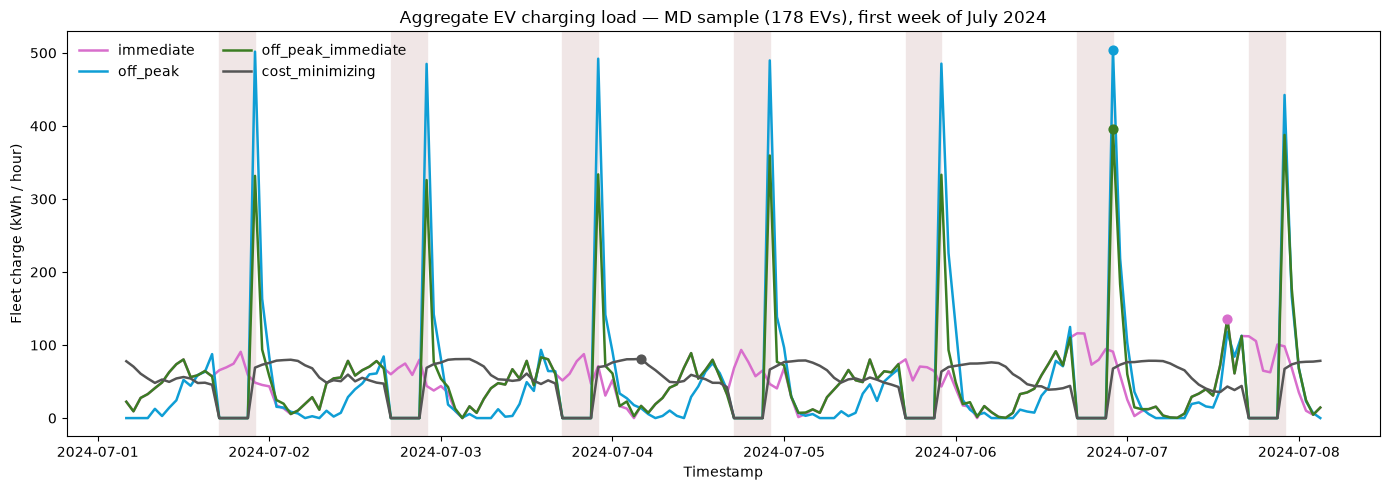

In [ ]:
STRATEGY_COLORS = {
    "immediate": COLOR_PINK,
    "off_peak": "#0F9ED5",
    "off_peak_immediate": COLOR_GREEN,
    "cost_minimizing": "#555555",
}
strategies_order = ["immediate", "off_peak", "off_peak_immediate", "cost_minimizing"]

fig, ax = plt.subplots(figsize=(14, 5))
ref = fleet_load_by_strategy["immediate"]
ts = ref["timestamp"].to_numpy()

# Shade peak hours once
for i, is_peak in enumerate(ref["is_peak"].to_list()):
    if is_peak:
        ax.axvspan(ts[i], ts[i] + np.timedelta64(1, "h"), color="#f0e6e6", zorder=0)

for strategy in strategies_order:
    load = fleet_load_by_strategy[strategy]
    ax.plot(
        load["timestamp"].to_numpy(),
        load["fleet_charge_kwh"].to_numpy(),
        color=STRATEGY_COLORS[strategy],
        linewidth=1.8,
        label=strategy,
    )
    # Mark the hour of maximum charge
    imax = int(np.argmax(load["fleet_charge_kwh"].to_numpy()))
    ax.scatter(
        [load["timestamp"].to_numpy()[imax]],
        [float(load["fleet_charge_kwh"][imax])],
        color=STRATEGY_COLORS[strategy],
        s=40,
        zorder=3,
    )

ax.set_ylabel("Fleet charge (kWh / hour)")
ax.set_xlabel("Timestamp")
ax.set_title(
    f"Aggregate EV charging load — {STATE} sample ({ev_attributes.height} EVs), "
    f"first week of July 2024"
)
ax.legend(frameon=False, ncols=2)
fig.tight_layout()
plt.show()


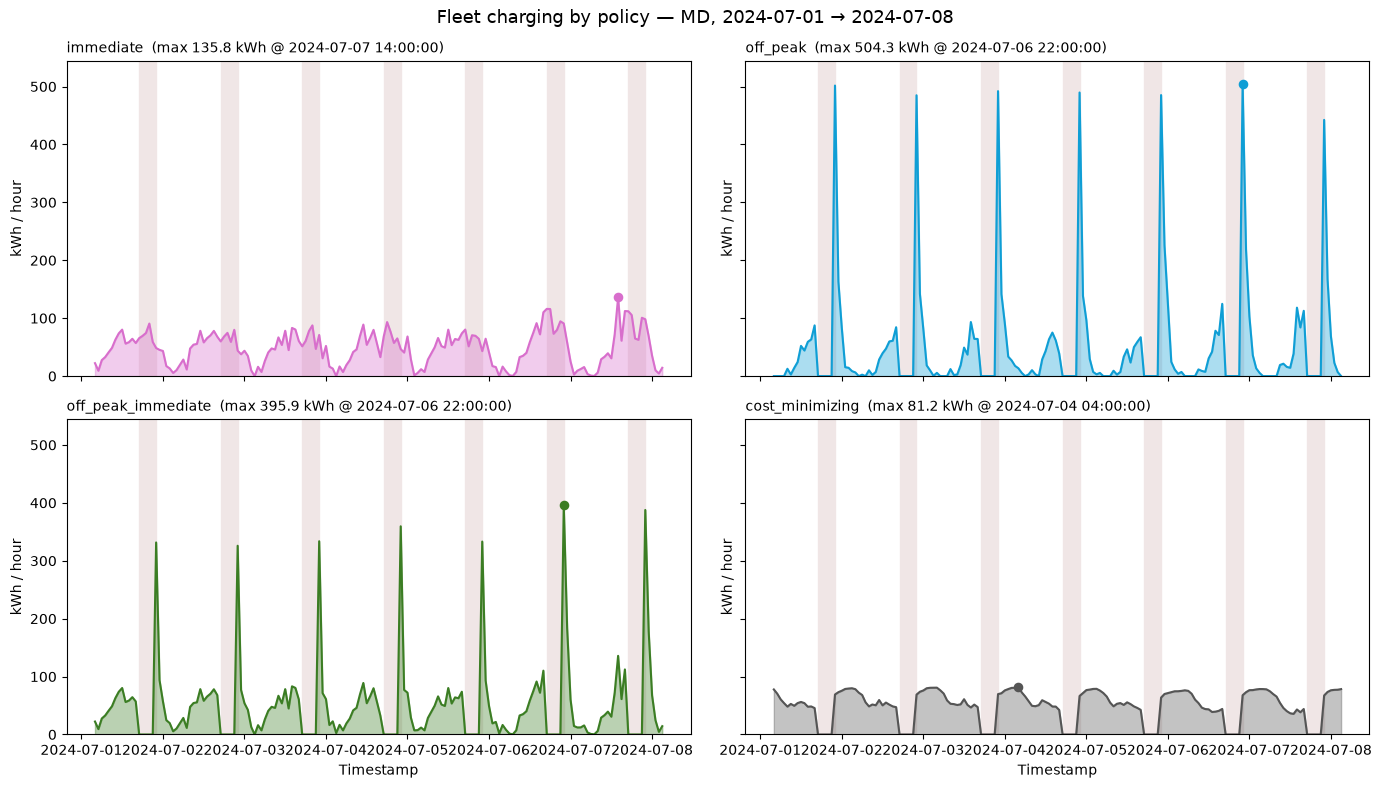

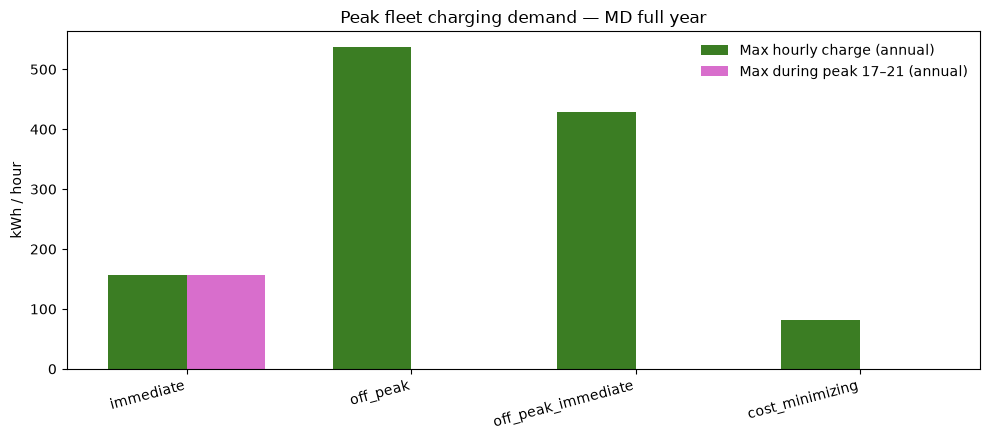

Hour of annual max fleet charge by strategy


strategy,annual_max_hourly_charge_kwh,hour_of_annual_max_charge
str,f64,datetime[μs]
"""immediate""",155.91,2024-10-20 17:00:00
"""off_peak""",536.55,2024-06-24 22:00:00
"""off_peak_immediate""",429.23,2024-01-20 22:00:00
"""cost_minimizing""",82.21,2024-02-29 03:00:00


In [ ]:
# 2×2 panels + peak-hour bar comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
fig.suptitle(
    f"Fleet charging by policy — {STATE}, {FLEET_WINDOW_START.date()} → "
    f"{(FLEET_WINDOW_END - timedelta(hours=3)).date()}",
    fontsize=13,
)

ymax = max(float(load["fleet_charge_kwh"].max()) for load in fleet_load_by_strategy.values()) * 1.08

for ax, strategy in zip(axes.ravel(), strategies_order):
    load = fleet_load_by_strategy[strategy]
    ts = load["timestamp"].to_numpy()
    vals = load["fleet_charge_kwh"].to_numpy()
    for i, is_peak in enumerate(load["is_peak"].to_list()):
        if is_peak:
            ax.axvspan(ts[i], ts[i] + np.timedelta64(1, "h"), color="#f0e6e6", zorder=0)
    ax.fill_between(ts, vals, color=STRATEGY_COLORS[strategy], alpha=0.35)
    ax.plot(ts, vals, color=STRATEGY_COLORS[strategy], linewidth=1.5)
    imax = int(np.argmax(vals))
    ax.scatter([ts[imax]], [vals[imax]], color=STRATEGY_COLORS[strategy], s=35, zorder=3)
    ax.set_ylim(0, ymax)
    ax.set_title(
        f"{strategy}  (max {vals[imax]:.1f} kWh @ {load['timestamp'][imax]})",
        loc="left",
        fontsize=10,
    )
    ax.set_ylabel("kWh / hour")

axes[1, 0].set_xlabel("Timestamp")
axes[1, 1].set_xlabel("Timestamp")
fig.tight_layout()
plt.show()

# Bar chart of annual peak metrics
summary = pl.DataFrame(fleet_summary_rows).sort(
    pl.col("strategy").replace({s: i for i, s in enumerate(strategies_order)})
)
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(summary.height)
width = 0.35
ax.bar(
    x - width / 2,
    summary["annual_max_hourly_charge_kwh"].to_numpy(),
    width,
    label="Max hourly charge (annual)",
    color=COLOR_GREEN,
)
ax.bar(
    x + width / 2,
    summary["annual_max_peak_hour_charge_kwh"].to_numpy(),
    width,
    label="Max during peak 17–21 (annual)",
    color=COLOR_PINK,
)
ax.set_xticks(x)
ax.set_xticklabels(summary["strategy"].to_list(), rotation=15, ha="right")
ax.set_ylabel("kWh / hour")
ax.set_title(f"Peak fleet charging demand — {STATE} full year")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print("Hour of annual max fleet charge by strategy")
display(summary.select("strategy", "annual_max_hourly_charge_kwh", "hour_of_annual_max_charge"))


## 9. Fleet charging vs base residential load

July-week 2×2 panels and annual peak bars, shown two ways:

1. **EV charging only** (same as §8)
2. **Base residential + EV** stacked

Load curves: `res_2024_amy2018_2_sb` for the 2024 TMY3 EV sample (no published TMY3
hourly loads here). Timestamps remapped 2018 → 2024 by calendar month/day/hour.
2024 baseline electricity has no EV end-use.


In [ ]:
LOAD_RELEASE = "res_2024_amy2018_2_sb"
PATH_LOADS_DIR = (
    Path("/ebs/data/nrel/resstock")
    / LOAD_RELEASE
    / "load_curve_hourly"
    / f"state={STATE}"
    / "upgrade=00"
)
ELEC_COL = "out.electricity.total.energy_consumption"

ev_bldg_ids = ev_attributes["bldg_id"].unique().to_list()
load_paths = [PATH_LOADS_DIR / f"{bid}-0.parquet" for bid in ev_bldg_ids]
missing = [p for p in load_paths if not p.exists()]
assert not missing, f"Missing load curves for {len(missing)} EV buildings (e.g. {missing[:3]})"

print(
    f"Loading base residential electricity for {len(load_paths):,} EV buildings "
    f"from {PATH_LOADS_DIR}"
)

# Sum unweighted kWh across EV buildings (same aggregation as fleet_charge_kwh)
base_residential_hourly = (
    pl.scan_parquet(load_paths)
    .select(
        "timestamp",
        pl.col(ELEC_COL).alias("base_elec_kwh"),
    )
    .group_by("timestamp")
    .agg(pl.col("base_elec_kwh").sum())
    .sort("timestamp")
    .with_columns(
        # Align AMY2018 clock to the 2024 NHTS simulation calendar
        pl.datetime(
            2024,
            pl.col("timestamp").dt.month(),
            pl.col("timestamp").dt.day(),
            pl.col("timestamp").dt.hour(),
        ).alias("timestamp"),
    )
    .collect()
)

base_residential_week = base_residential_hourly.filter(
    (pl.col("timestamp") >= FLEET_WINDOW_START) & (pl.col("timestamp") <= FLEET_WINDOW_END)
).sort("timestamp")

print(
    f"Base residential hours: {base_residential_hourly.height:,}  "
    f"July-week hours: {base_residential_week.height:,}  "
    f"week mean={base_residential_week['base_elec_kwh'].mean():.1f} kWh/h  "
    f"week max={base_residential_week['base_elec_kwh'].max():.1f} kWh/h"
)

# Combined annual series for peak bars (inner-join drops 2024-02-29; AMY2018 has no leap day)
combined_annual_by_strategy = {}
combined_summary_rows = []
base_annual_max = float(base_residential_hourly["base_elec_kwh"].max())

for strategy in strategies_order:
    annual = fleet_annual_load_by_strategy[strategy].join(
        base_residential_hourly, on="timestamp", how="inner"
    ).with_columns(
        (pl.col("base_elec_kwh") + pl.col("fleet_charge_kwh")).alias("total_elec_kwh")
    )
    combined_annual_by_strategy[strategy] = annual
    total = annual["total_elec_kwh"]
    total_peak = annual.filter(pl.col("is_peak"))["total_elec_kwh"]
    hour_of_max = annual.sort("total_elec_kwh", descending=True)["timestamp"][0]
    combined_summary_rows.append({
        "strategy": strategy,
        "annual_max_hourly_base_kwh": round(base_annual_max, 2),
        "annual_max_hourly_ev_kwh": round(float(annual["fleet_charge_kwh"].max()), 2),
        "annual_max_hourly_total_kwh": round(float(total.max()), 2),
        "annual_max_peak_hour_total_kwh": round(
            float(total_peak.max()) if total_peak.len() else 0.0, 2
        ),
        "hour_of_annual_max_total": hour_of_max,
    })

display(pl.DataFrame(combined_summary_rows))


Loading base residential electricity for 178 EV buildings from /ebs/data/nrel/resstock/res_2024_amy2018_2_sb/load_curve_hourly/state=MD/upgrade=00
Base residential hours: 8,760  July-week hours: 168  week mean=447.4 kWh/h  week max=687.3 kWh/h


strategy,annual_max_hourly_base_kwh,annual_max_hourly_ev_kwh,annual_max_hourly_total_kwh,annual_max_peak_hour_total_kwh,hour_of_annual_max_total
str,f64,f64,f64,f64,datetime[μs]
"""immediate""",945.39,155.91,981.75,981.75,2024-01-06 18:00:00
"""off_peak""",945.39,536.55,1123.22,897.97,2024-01-17 22:00:00
"""off_peak_immediate""",945.39,429.23,1220.27,897.97,2024-01-06 22:00:00
"""cost_minimizing""",945.39,81.94,988.18,897.97,2024-01-07 07:00:00


=== EV charging only ===


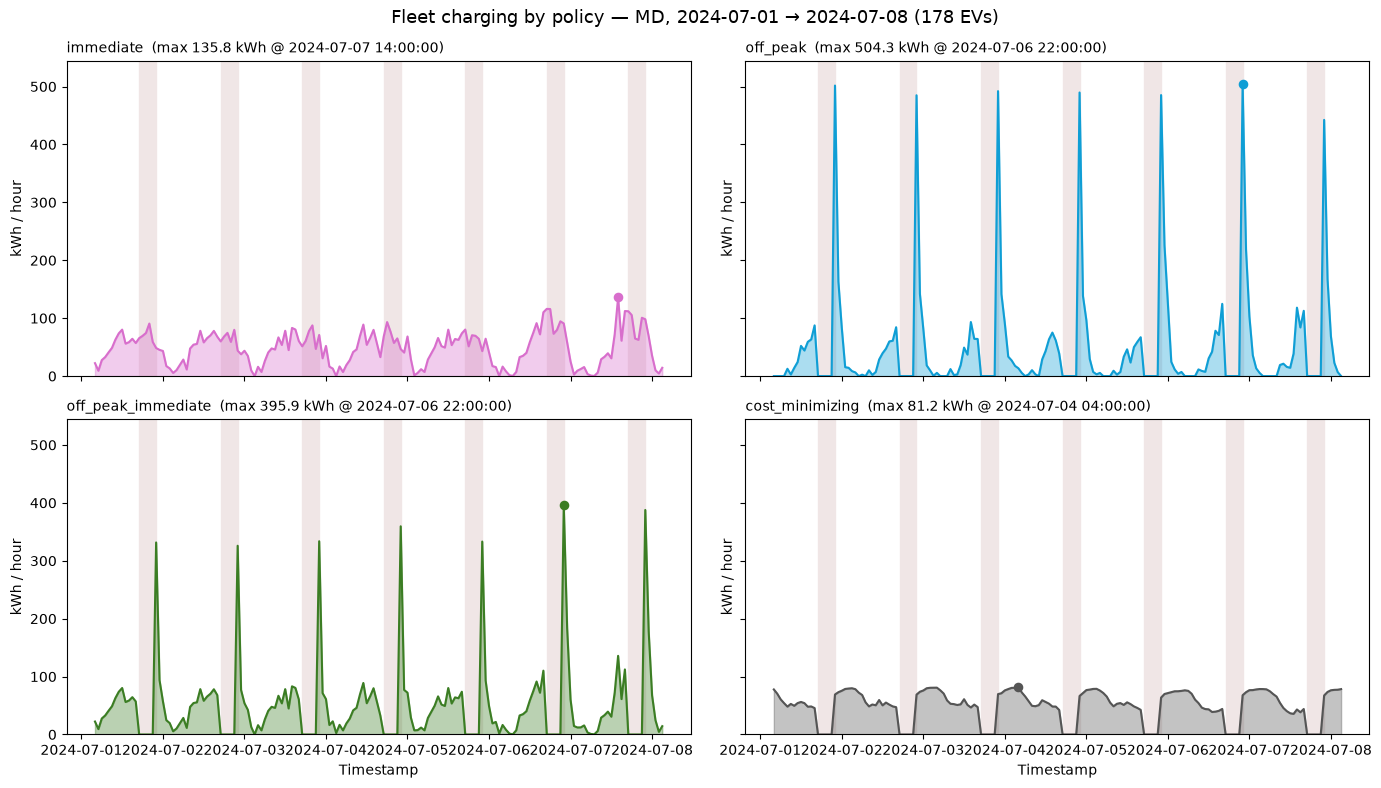

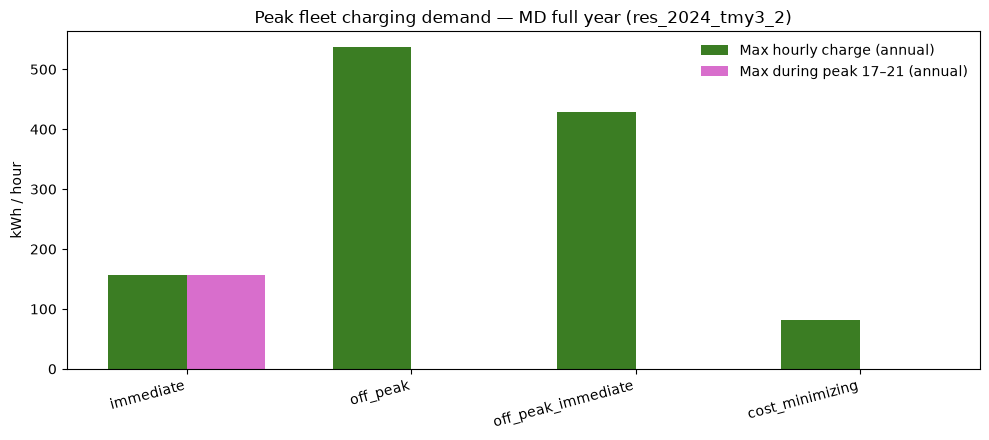

Hour of annual max fleet charge by strategy


strategy,annual_max_hourly_charge_kwh,hour_of_annual_max_charge
str,f64,datetime[μs]
"""immediate""",155.91,2024-10-20 17:00:00
"""off_peak""",536.55,2024-06-24 22:00:00
"""off_peak_immediate""",429.23,2024-01-20 22:00:00
"""cost_minimizing""",82.21,2024-02-29 03:00:00


=== Base residential + EV charging ===


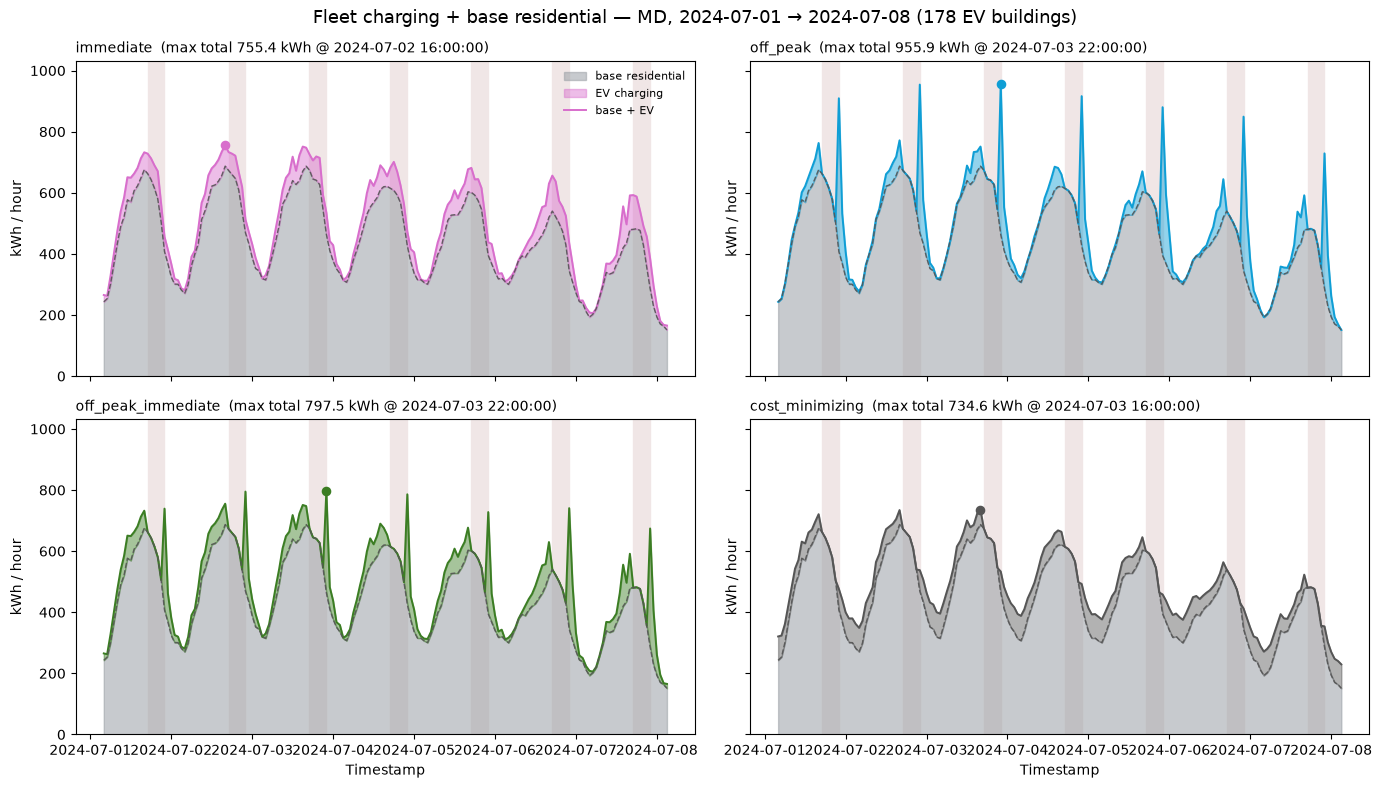

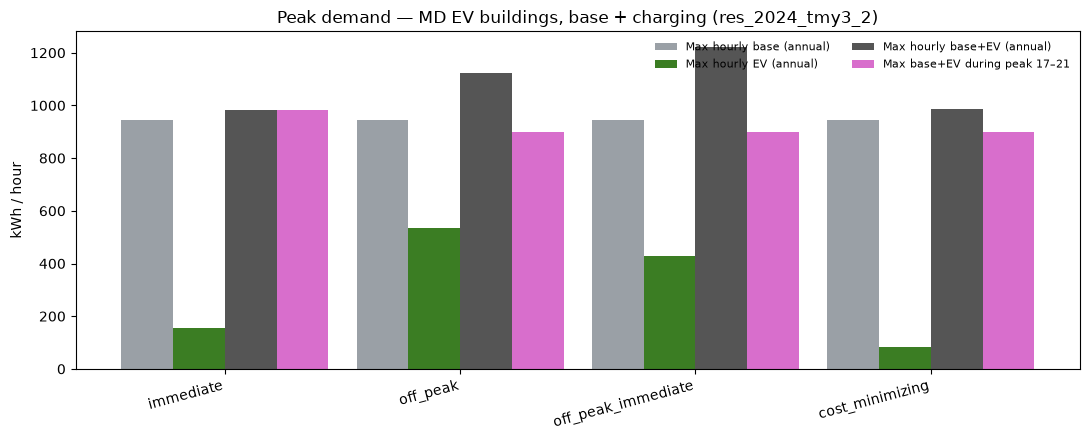

Hour of annual max base+EV load by strategy


strategy,annual_max_hourly_total_kwh,hour_of_annual_max_total
str,f64,datetime[μs]
"""immediate""",981.75,2024-01-06 18:00:00
"""off_peak""",1123.22,2024-01-17 22:00:00
"""off_peak_immediate""",1220.27,2024-01-06 22:00:00
"""cost_minimizing""",988.18,2024-01-07 07:00:00


In [ ]:
COLOR_BASE = "#9AA0A6"


def plot_fleet_ev_only(
    load_by_strategy: dict[str, pl.DataFrame],
    summary_rows: list[dict],
    *,
    title_week: str,
    title_bars: str,
) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
    fig.suptitle(title_week, fontsize=13)
    ymax = max(float(load["fleet_charge_kwh"].max()) for load in load_by_strategy.values()) * 1.08

    for ax, strategy in zip(axes.ravel(), strategies_order, strict=False):
        load = load_by_strategy[strategy]
        ts = load["timestamp"].to_numpy()
        vals = load["fleet_charge_kwh"].to_numpy()
        for i, is_peak in enumerate(load["is_peak"].to_list()):
            if is_peak:
                ax.axvspan(ts[i], ts[i] + np.timedelta64(1, "h"), color="#f0e6e6", zorder=0)
        ax.fill_between(ts, vals, color=STRATEGY_COLORS[strategy], alpha=0.35)
        ax.plot(ts, vals, color=STRATEGY_COLORS[strategy], linewidth=1.5)
        imax = int(np.argmax(vals))
        ax.scatter([ts[imax]], [vals[imax]], color=STRATEGY_COLORS[strategy], s=35, zorder=3)
        ax.set_ylim(0, ymax)
        ax.set_title(
            f"{strategy}  (max {vals[imax]:.1f} kWh @ {load['timestamp'][imax]})",
            loc="left",
            fontsize=10,
        )
        ax.set_ylabel("kWh / hour")

    axes[1, 0].set_xlabel("Timestamp")
    axes[1, 1].set_xlabel("Timestamp")
    fig.tight_layout()
    plt.show()

    summary = pl.DataFrame(summary_rows).sort(
        pl.col("strategy").replace({s: i for i, s in enumerate(strategies_order)})
    )
    fig, ax = plt.subplots(figsize=(10, 4.5))
    x = np.arange(summary.height)
    width = 0.35
    ax.bar(
        x - width / 2,
        summary["annual_max_hourly_charge_kwh"].to_numpy(),
        width,
        label="Max hourly charge (annual)",
        color=COLOR_GREEN,
    )
    ax.bar(
        x + width / 2,
        summary["annual_max_peak_hour_charge_kwh"].to_numpy(),
        width,
        label="Max during peak 17–21 (annual)",
        color=COLOR_PINK,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(summary["strategy"].to_list(), rotation=15, ha="right")
    ax.set_ylabel("kWh / hour")
    ax.set_title(title_bars)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

    print("Hour of annual max fleet charge by strategy")
    display(summary.select("strategy", "annual_max_hourly_charge_kwh", "hour_of_annual_max_charge"))


def plot_fleet_ev_plus_base(
    load_by_strategy: dict[str, pl.DataFrame],
    base_week: pl.DataFrame,
    combined_summary_rows: list[dict],
    *,
    title_week: str,
    title_bars: str,
) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
    fig.suptitle(title_week, fontsize=13)

    ymax = 0.0
    for strategy in strategies_order:
        load = load_by_strategy[strategy].join(
            base_week.select("timestamp", "base_elec_kwh"), on="timestamp", how="inner"
        )
        ymax = max(ymax, float((load["base_elec_kwh"] + load["fleet_charge_kwh"]).max()))
    ymax *= 1.08

    for ax, strategy in zip(axes.ravel(), strategies_order, strict=False):
        load = (
            load_by_strategy[strategy]
            .join(base_week.select("timestamp", "base_elec_kwh"), on="timestamp", how="inner")
            .sort("timestamp")
        )
        ts = load["timestamp"].to_numpy()
        base = load["base_elec_kwh"].to_numpy()
        ev = load["fleet_charge_kwh"].to_numpy()
        total = base + ev

        for i, is_peak in enumerate(load["is_peak"].to_list()):
            if is_peak:
                ax.axvspan(ts[i], ts[i] + np.timedelta64(1, "h"), color="#f0e6e6", zorder=0)

        ax.fill_between(ts, 0, base, color=COLOR_BASE, alpha=0.55, label="base residential")
        ax.fill_between(
            ts, base, total, color=STRATEGY_COLORS[strategy], alpha=0.45, label="EV charging"
        )
        ax.plot(ts, total, color=STRATEGY_COLORS[strategy], linewidth=1.4, label="base + EV")
        ax.plot(ts, base, color="#555555", linewidth=1.0, linestyle="--", alpha=0.9)

        imax = int(np.argmax(total))
        ax.scatter([ts[imax]], [total[imax]], color=STRATEGY_COLORS[strategy], s=35, zorder=3)
        ax.set_ylim(0, ymax)
        ax.set_title(
            f"{strategy}  (max total {total[imax]:.1f} kWh @ {load['timestamp'][imax]})",
            loc="left",
            fontsize=10,
        )
        ax.set_ylabel("kWh / hour")

    axes[0, 0].legend(frameon=False, fontsize=8, loc="upper right")
    axes[1, 0].set_xlabel("Timestamp")
    axes[1, 1].set_xlabel("Timestamp")
    fig.tight_layout()
    plt.show()

    summary_combined = pl.DataFrame(combined_summary_rows).sort(
        pl.col("strategy").replace({s: i for i, s in enumerate(strategies_order)})
    )
    fig, ax = plt.subplots(figsize=(11, 4.5))
    x = np.arange(summary_combined.height)
    width = 0.22
    ax.bar(
        x - 1.5 * width,
        summary_combined["annual_max_hourly_base_kwh"].to_numpy(),
        width,
        label="Max hourly base (annual)",
        color=COLOR_BASE,
    )
    ax.bar(
        x - 0.5 * width,
        summary_combined["annual_max_hourly_ev_kwh"].to_numpy(),
        width,
        label="Max hourly EV (annual)",
        color=COLOR_GREEN,
    )
    ax.bar(
        x + 0.5 * width,
        summary_combined["annual_max_hourly_total_kwh"].to_numpy(),
        width,
        label="Max hourly base+EV (annual)",
        color="#555555",
    )
    ax.bar(
        x + 1.5 * width,
        summary_combined["annual_max_peak_hour_total_kwh"].to_numpy(),
        width,
        label="Max base+EV during peak 17–21",
        color=COLOR_PINK,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(summary_combined["strategy"].to_list(), rotation=15, ha="right")
    ax.set_ylabel("kWh / hour")
    ax.set_title(title_bars)
    ax.legend(frameon=False, fontsize=8, ncols=2)
    fig.tight_layout()
    plt.show()

    print("Hour of annual max base+EV load by strategy")
    display(
        summary_combined.select(
            "strategy", "annual_max_hourly_total_kwh", "hour_of_annual_max_total"
        )
    )


week_label = (
    f"{STATE}, {FLEET_WINDOW_START.date()} → {(FLEET_WINDOW_END - timedelta(hours=3)).date()}"
)

print("=== EV charging only ===")
plot_fleet_ev_only(
    fleet_load_by_strategy,
    fleet_summary_rows,
    title_week=f"Fleet charging by policy — {week_label} ({ev_attributes.height} EVs)",
    title_bars=f"Peak fleet charging demand — {STATE} full year ({config.release})",
)

print("=== Base residential + EV charging ===")
plot_fleet_ev_plus_base(
    fleet_load_by_strategy,
    base_residential_week,
    combined_summary_rows,
    title_week=(
        f"Fleet charging + base residential — {week_label} "
        f"({ev_attributes.height} EV buildings)"
    ),
    title_bars=f"Peak demand — {STATE} EV buildings, base + charging ({config.release})",
)


### ResStock 2025 MD — published July-week loads

Aggregate **NREL’s** hourly EV charging and base residential electricity for MD buildings
with `in.electric_vehicle_ownership == Yes` (no re-simulation of our charging policies).

- EV: `out.electricity.ev_charging.energy_consumption..kwh`
- Base: `out.electricity.total` − EV charging
- Window: first week of July (AMY2018 clock remapped to the notebook’s 2024 July labels)


In [ ]:
# Published ResStock 2025 loads for NREL EV owners (same July week as §8/§9)
PATH_LOADS_DIR_2025 = (
    Path("/ebs/data/nrel/resstock")
    / RELEASE_2025
    / "load_curve_hourly"
    / f"state={STATE}"
    / "upgrade=00"
)
ELEC_TOTAL_2025 = "out.electricity.total.energy_consumption..kwh"
ELEC_EV_2025 = "out.electricity.ev_charging.energy_consumption..kwh"

ev_bldg_ids_2025 = bldg_ev_2025.filter(pl.col("has_ev"))["bldg_id"].unique().to_list()
load_paths_2025 = [PATH_LOADS_DIR_2025 / f"{bid}-0.parquet" for bid in ev_bldg_ids_2025]
missing_2025 = [p for p in load_paths_2025 if not p.exists()]
assert not missing_2025, (
    f"Missing 2025 load curves for {len(missing_2025)} EV buildings (e.g. {missing_2025[:3]})"
)

print(
    f"Loading published loads for {len(load_paths_2025):,} NREL EV buildings "
    f"from {PATH_LOADS_DIR_2025}"
)

nrel_hourly_2025 = (
    pl.scan_parquet(load_paths_2025)
    .select(
        "timestamp",
        pl.col(ELEC_EV_2025).cast(pl.Float64).alias("ev_charge_kwh"),
        (
            pl.col(ELEC_TOTAL_2025).cast(pl.Float64)
            - pl.col(ELEC_EV_2025).cast(pl.Float64)
        ).alias("base_elec_kwh"),
    )
    .group_by("timestamp")
    .agg(
        pl.col("ev_charge_kwh").sum(),
        pl.col("base_elec_kwh").sum(),
    )
    .sort("timestamp")
    .with_columns(
        pl.datetime(
            2024,
            pl.col("timestamp").dt.month(),
            pl.col("timestamp").dt.day(),
            pl.col("timestamp").dt.hour(),
        ).alias("timestamp"),
    )
    .with_columns(
        (pl.col("base_elec_kwh") + pl.col("ev_charge_kwh")).alias("total_elec_kwh"),
        pl.col("timestamp").dt.hour().is_in(list(fleet_peak_hours)).alias("is_peak"),
    )
    .collect()
)

nrel_week_2025 = nrel_hourly_2025.filter(
    (pl.col("timestamp") >= FLEET_WINDOW_START) & (pl.col("timestamp") <= FLEET_WINDOW_END)
).sort("timestamp")

print(
    f"July-week hours: {nrel_week_2025.height:,}  "
    f"EV mean={nrel_week_2025['ev_charge_kwh'].mean():.1f}  "
    f"EV max={nrel_week_2025['ev_charge_kwh'].max():.1f}  "
    f"base max={nrel_week_2025['base_elec_kwh'].max():.1f}  "
    f"total max={nrel_week_2025['total_elec_kwh'].max():.1f} kWh/h"
)

# Peak EV charging (published ResStock end-use)
week_peak_row = nrel_week_2025.sort("ev_charge_kwh", descending=True).row(0, named=True)
annual_peak_row = nrel_hourly_2025.sort("ev_charge_kwh", descending=True).row(0, named=True)
peak_hours_annual = nrel_hourly_2025.filter(pl.col("is_peak"))
peak_window_row = peak_hours_annual.sort("ev_charge_kwh", descending=True).row(0, named=True)

print(f"\nPeak EV charging load — {RELEASE_2025} MD ({len(ev_bldg_ids_2025)} NREL EVs)")
print(
    f"  July-week max hourly EV:     {week_peak_row['ev_charge_kwh']:.2f} kWh/h "
    f"@ {week_peak_row['timestamp']}"
)
print(
    f"  Annual max hourly EV:        {annual_peak_row['ev_charge_kwh']:.2f} kWh/h "
    f"@ {annual_peak_row['timestamp']}"
)
print(
    f"  Annual max during peak 17–21: {peak_window_row['ev_charge_kwh']:.2f} kWh/h "
    f"@ {peak_window_row['timestamp']}"
)

total_peak_row = nrel_hourly_2025.sort("total_elec_kwh", descending=True).row(0, named=True)
print(
    f"  Annual max base+EV:          {total_peak_row['total_elec_kwh']:.2f} kWh/h "
    f"@ {total_peak_row['timestamp']} "
    f"(base={total_peak_row['base_elec_kwh']:.2f}, EV={total_peak_row['ev_charge_kwh']:.2f})"
)

display(
    nrel_week_2025.select(
        "ev_charge_kwh", "base_elec_kwh", "total_elec_kwh"
    ).describe()
)


Loading published loads for 127 NREL EV buildings from /ebs/data/nrel/resstock/res_2025_amy2018_1/load_curve_hourly/state=MD/upgrade=00
July-week hours: 168  EV mean=31.3  EV max=116.8  base max=557.4  total max=636.8 kWh/h

Peak EV charging load — res_2025_amy2018_1 MD (127 NREL EVs)
  July-week max hourly EV:     116.79 kWh/h @ 2024-07-05 19:00:00
  Annual max hourly EV:        164.76 kWh/h @ 2024-01-02 21:00:00
  Annual max during peak 17–21: 164.76 kWh/h @ 2024-01-02 21:00:00
  Annual max base+EV:          797.86 kWh/h @ 2024-01-04 19:00:00 (base=665.26, EV=132.60)


statistic,ev_charge_kwh,base_elec_kwh,total_elec_kwh
str,f64,f64,f64
"""count""",168.0,168.0,168.0
"""null_count""",0.0,0.0,0.0
"""mean""",31.262884,352.833296,384.096181
"""std""",26.700816,114.480074,132.160644
"""min""",1.49617,109.14478,116.55452
"""25%""",10.08616,262.34731,275.57046
"""50%""",20.23163,344.26464,371.406291
"""75%""",49.68157,453.062906,492.714289
"""max""",116.79164,557.357212,636.826182


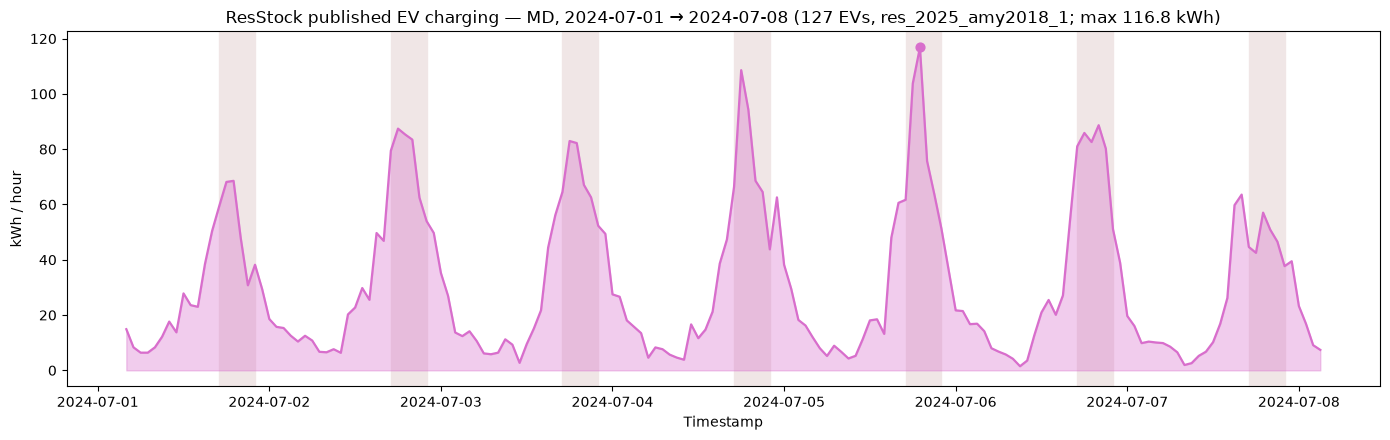

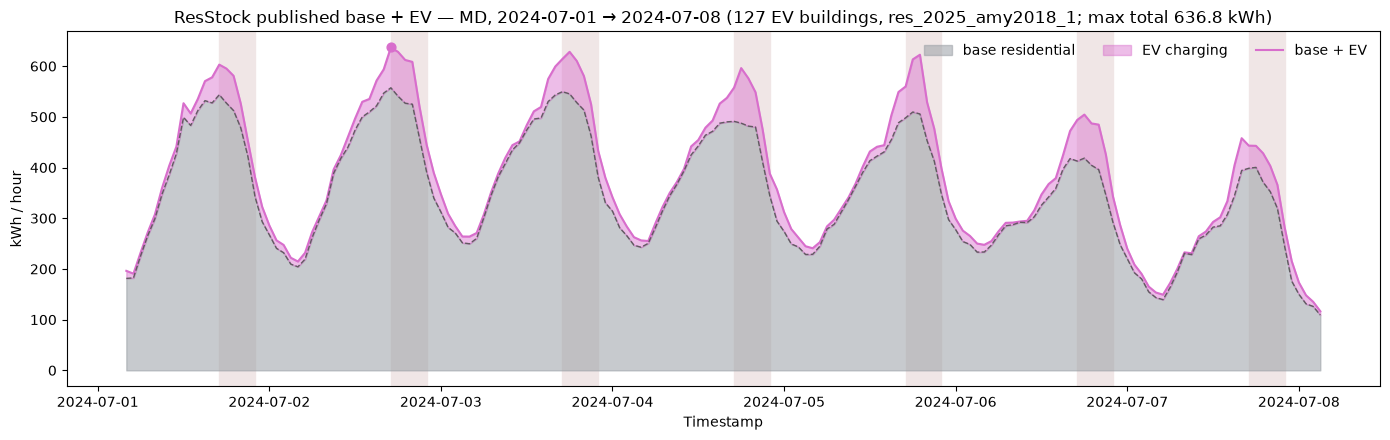

In [ ]:
week_label_2025 = (
    f"{STATE}, {FLEET_WINDOW_START.date()} → {(FLEET_WINDOW_END - timedelta(hours=3)).date()}"
)
n_ev_2025 = len(ev_bldg_ids_2025)
ts = nrel_week_2025["timestamp"].to_numpy()
ev = nrel_week_2025["ev_charge_kwh"].to_numpy()
base = nrel_week_2025["base_elec_kwh"].to_numpy()
total = nrel_week_2025["total_elec_kwh"].to_numpy()
is_peak = nrel_week_2025["is_peak"].to_list()

def _shade_peak(ax):
    for i, peak in enumerate(is_peak):
        if peak:
            ax.axvspan(ts[i], ts[i] + np.timedelta64(1, "h"), color="#f0e6e6", zorder=0)

# 1) EV charging only
fig, ax = plt.subplots(figsize=(14, 4.5))
_shade_peak(ax)
ax.fill_between(ts, ev, color=COLOR_PINK, alpha=0.35)
ax.plot(ts, ev, color=COLOR_PINK, linewidth=1.6)
imax = int(np.argmax(ev))
ax.scatter([ts[imax]], [ev[imax]], color=COLOR_PINK, s=40, zorder=3)
ax.set_ylabel("kWh / hour")
ax.set_xlabel("Timestamp")
ax.set_title(
    f"ResStock published EV charging — {week_label_2025} "
    f"({n_ev_2025} EVs, {RELEASE_2025}; max {ev[imax]:.1f} kWh)",
    fontsize=12,
)
fig.tight_layout()
plt.show()

# 2) Base residential + EV charging
fig, ax = plt.subplots(figsize=(14, 4.5))
_shade_peak(ax)
ax.fill_between(ts, 0, base, color=COLOR_BASE, alpha=0.55, label="base residential")
ax.fill_between(ts, base, total, color=COLOR_PINK, alpha=0.45, label="EV charging")
ax.plot(ts, total, color=COLOR_PINK, linewidth=1.5, label="base + EV")
ax.plot(ts, base, color="#555555", linewidth=1.0, linestyle="--", alpha=0.9)
imax = int(np.argmax(total))
ax.scatter([ts[imax]], [total[imax]], color=COLOR_PINK, s=40, zorder=3)
ax.set_ylabel("kWh / hour")
ax.set_xlabel("Timestamp")
ax.set_title(
    f"ResStock published base + EV — {week_label_2025} "
    f"({n_ev_2025} EV buildings, {RELEASE_2025}; max total {total[imax]:.1f} kWh)",
    fontsize=12,
)
ax.legend(frameon=False, ncols=3)
fig.tight_layout()
plt.show()
